---
## 🔧 0. Setup del Trabajo

Aclaraciones previas:
> Las tasas de mercado (Rf, ERP, spread) están **fijadas a un snapshot de Damodaran (abril 2026)**
> para que la valuación sea **reproducible**; los datos de precio/acciones/deuda se bajan en vivo de
> Yahoo Finance, por lo que el precio objetivo puede variar levemente según el día de corrida.

# 📊 Trabajo Final — Valuación de Apple Inc. (AAPL)
### Seminario: ¿Cuánto vale una empresa?

> Valuación fundamental por **Flujos de Fondos Descontados (FFD)**, integrando construcción de la tasa de descuento (WACC) con el descuento del flujo proyectado y el modelo de Gordon-Shapiro para el valor terminal.

---

### 🗺️ Roadmap del trabajo

```
   PARTE 1: COSTO DE CAPITAL                         PARTE 2: VALUACIÓN
   ─────────────────────────                         ──────────────────

   Apple en un vistazo                               FCF Proyectados (cátedra)
        │                                                     │
        ▼                                                     ▼
   Análisis por Múltiplos                            Descuento al WACC
        │                                                     │
        ▼                                                     ▼
   Costo Deuda (Kd)  +  Tax Rate                    Valor Terminal (Gordon)
        │                                                     │
        ▼                                                     ▼
   CAPM: Beta + Beta unlev. + Ke                    Enterprise Value
        │                                                     │
        ▼                                                     ▼
   WACC ──────────────────────────────►              − Deuda Neta
                                                             │
                                                             ▼
                                                    Equity Value / N° acciones
                                                             │
                                                             ▼
                                                    PRECIO OBJETIVO
                                                             │
                                                             ▼
                                              Sensibilidad + Escenarios
                                                             │
                                                             ▼
                                              ¿Comprar / Mantener / Vender?
```

### 🧠 Dos ecuaciones centrales para el trabajo

**Tasa de descuento (Parte 1):**
$$ \text{WACC} = \frac{E}{E+D} \cdot K_e + \frac{D}{E+D} \cdot K_d \cdot (1-T) $$

**Valuación intrínseca (Parte 2):**
$$ \text{Enterprise Value} = \sum_{t=1}^{5} \frac{FCF_t}{(1+WACC)^t} + \frac{TV_{2030}}{(1+WACC)^5}, \quad TV_{2030} = \frac{FCF_{2030} \cdot (1+g)}{WACC - g} $$


In [135]:
# Instalación
!pip install -q yfinance statsmodels --upgrade

In [136]:
# Imports
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# Parámetros globales del trabajo
TICKER = 'AAPL'
BENCHMARK = '^GSPC'                      # S&P 500
PEERS = ['MSFT', 'GOOGL', 'META', 'AMZN']  # comparables tech mega-cap

# Ventana para la regresión de beta: 5 años de datos mensuales (estándar Bloomberg)
END_DATE = datetime.today()
START_DATE = END_DATE - timedelta(days=365 * 5)

print(f'Empresa objetivo : {TICKER}')
print(f'Benchmark        : {BENCHMARK}')
print(f'Comparables      : {PEERS}')
print(f'Ventana de beta  : {START_DATE.date()} → {END_DATE.date()}')

Empresa objetivo : AAPL
Benchmark        : ^GSPC
Comparables      : ['MSFT', 'GOOGL', 'META', 'AMZN']
Ventana de beta  : 2021-05-31 → 2026-05-30


---
## ⚙️ Parámetros del modelo (snapshot Damodaran, abril 2026)

Fijamos las tasas de mercado (Rf, ERP, spread de crédito) a un **snapshot** para que la valuación sea **reproducible** y para que Rf y ERP provengan del **mismo** modelo de Damodaran (`ERPApril26_1.xlsx`). Es una única fuente de verdad que el resto del notebook referencia.

In [137]:
# ============================================================================
#  PARÁMETROS DEL MODELO — Snapshot Damodaran, abril 2026  (ERPApril26_1.xlsx)
#  Única fuente de verdad para Rf, ERP y el spread de crédito.
# ============================================================================
DAMODARAN_SNAPSHOT = 'April 2026'

# Tasa libre de riesgo: US 10Y Treasury (ERPApril26_1.xlsx → "current 10-year US treasury")
RF = 0.0432                 # 4.32%
RF_TREASURY_10Y = RF        # alias usado en el cálculo de Kd (mismo valor, una sola fuente)

# Equity Risk Premium implícito (forward-looking), Damodaran abr-26
# Fuente exacta: ERPApril26_1.xlsx → "Implied Equity Risk Premium (with US treasury rate)" = 4.7741%
ERP = 0.0477               # 4.77%

# Spread de crédito synthetic para el Kd. Apple = máxima calidad (Aa1/Aaa Moody's, AA+ S&P).
# Usamos el spread Aa1 que Damodaran fija en ERPApril26_1.xlsx ("Default spread for Aa1 rating").
APPLE_RATING = "Aa1 / Aaa (Moody's) · AA+ (S&P)"
APPLE_SPREAD = 0.0026      # 26 bps (Damodaran abr-26, Aa1)

print(f'Snapshot Damodaran        : {DAMODARAN_SNAPSHOT}')
print(f'Rf (US Treasury 10Y)      : {RF*100:.2f}%')
print(f'ERP implícito             : {ERP*100:.2f}%')
print(f'Rating Apple / spread Kd  : {APPLE_RATING}  →  {APPLE_SPREAD*100:.2f}%')

Snapshot Damodaran        : April 2026
Rf (US Treasury 10Y)      : 4.32%
ERP implícito             : 4.77%
Rating Apple / spread Kd  : Aa1 / Aaa (Moody's) · AA+ (S&P)  →  0.26%


---
# 📐 PARTE 1 — Costo de Capital (WACC)

Construimos la tasa de descuento que después usaremos para traer a valor presente los flujos proyectados.

---
## 🍎 1. Apple Inc. en un vistazo

In [138]:
apple = yf.Ticker(TICKER)
info = apple.info

resumen = {
    'Nombre':              info.get('longName'),
    'Sector':              info.get('sector'),
    'Industria':           info.get('industry'),
    'País':                info.get('country'),
    'Empleados':           f"{info.get('fullTimeEmployees', 0):,}",
    'Market Cap (USD bn)': f"{info.get('marketCap', 0)/1e9:,.1f}",
    'Precio actual (USD)': f"{info.get('currentPrice', 0):,.2f}",
    'Beta (yfinance)':     info.get('beta'),
    'P/E (TTM)':           round(info.get('trailingPE', 0), 2) if info.get('trailingPE') else None,
    'Dividend yield':      f"{(info.get('dividendYield') or 0)*100:.2f}%",
}
pd.DataFrame(resumen.items(), columns=['Indicador', 'Valor'])

,Indicador,Valor
0,Nombre,Apple Inc.
1,Sector,Technology
2,Industria,Consumer Electronics
3,País,United States
4,Empleados,"166,000"
5,Market Cap (USD bn),"4,583.3"
6,Precio actual (USD),312.06
7,Beta (yfinance),1.065
8,P/E (TTM),37.73
9,Dividend yield,35.00%


## ¿De dónde provienen los ingresos de Apple?

Apple factura por dos bloques (FY2025: US$416 B totales):

* **Productos (~74%):** iPhone (~50% del total), Mac, iPad, Apple Watch, AirPods.
* **Servicios (~26%):** App Store, iCloud, Apple Music, Apple TV+, AppleCare,
  Apple Pay y el pago de Google por ser buscador por defecto en Safari (~US$20 B/año).

**Modelo de negocio:** el iPhone es la *puerta de entrada* al ecosistema. Una vez
dentro, Apple monetiza esa base instalada (>2.000 M de dispositivos activos) con
Servicios, cobrando comisiones del 15-30% sin fabricar nada físico.

**El dato clave — márgenes:**

| | Margen bruto | Por qué |
|---|---|---|
| Productos | ~38% | Lleva materiales, fábrica, ensamblado, logística |
| Servicios | ~75% | Costo marginal casi cero: sumar un usuario no cuesta |

**Por qué importa para la valuación:**

1. **Expansión de margen:** Servicios pasó del ~20% al ~26% del mix; cada punto
   que gana mejora la rentabilidad total sin vender más hardware.
2. **Ingresos más estables:** suscripciones recurrentes vs. el iPhone, que es
   cíclico → menor riesgo → múltiplo más alto.
3. **Colchón:** aunque el iPhone se estanque, la base instalada sigue generando
   Servicios.

> En ganancia bruta, **Servicios ya aporta casi tanto como todo el iPhone, con la
> mitad de la facturación.** Es el principal motor de rentabilidad de Apple.

**Riesgo a monitorear:** el acuerdo con Google (~US$20 B/año, casi todo margen)
fue avalado por la Justicia en sept-2025, pero ya no es exclusivo, se renegocia
anual y Google apeló. Un cambio impactaría de lleno en la parte más rentable.

---
## 📐 2. Análisis por Múltiplos — Valuación Relativa

La valuación por múltiplos es una "foto" del precio que el mercado le pone hoy a empresas similares a Apple. **No reemplaza al FFD** (que es un análisis intrínseco), pero sirve como **chequeo de razonabilidad**.

| Múltiplo | Fórmula | Qué mide |
|---|---|---|
| **P/E** | Precio / EPS | Cuántos años de ganancias paga el inversor |
| **EV/EBITDA** | Enterprise Value / EBITDA | Independiente de estructura de capital y de impuestos |
| **P/S** | Precio / Ventas | Útil con ganancias volátiles o negativas |
| **P/B** | Precio / Valor libros | Cuánto se paga sobre el patrimonio contable |

In [139]:
def get_multiples(ticker):
    info_t = yf.Ticker(ticker).info
    return {
        'Ticker':       ticker,
        'Nombre':       info_t.get('shortName'),
        'Mkt Cap (B)':  round((info_t.get('marketCap') or 0) / 1e9, 1),
        'P/E (TTM)':    info_t.get('trailingPE'),
        'P/E (Fwd)':    info_t.get('forwardPE'),
        'EV/EBITDA':    info_t.get('enterpriseToEbitda'),
        'P/S (TTM)':    info_t.get('priceToSalesTrailing12Months'),
        'P/B':          info_t.get('priceToBook'),
        'Margen Op.':   info_t.get('operatingMargins'),
        'ROE':          info_t.get('returnOnEquity'),
    }

datos = [get_multiples(t) for t in [TICKER] + PEERS]
df_mult = pd.DataFrame(datos).set_index('Ticker')

peers_df = df_mult.loc[PEERS, ['P/E (TTM)', 'P/E (Fwd)', 'EV/EBITDA', 'P/S (TTM)', 'P/B']]
df_mult.loc['Promedio peers'] = ['—', '—'] + list(peers_df.mean())   + ['—', '—']
df_mult.loc['Mediana peers']  = ['—', '—'] + list(peers_df.median()) + ['—', '—']

display_df = df_mult.copy()

# Formateo numérico de múltiplos
for c in ['P/E (TTM)', 'P/E (Fwd)', 'EV/EBITDA', 'P/S (TTM)', 'P/B']:
    display_df[c] = display_df[c].apply(lambda x: f'{x:.1f}x' if pd.notna(x) else '—')

# Formateo de porcentajes (sirve tanto para None como para '—')
for c in ['Margen Op.', 'ROE']:
    display_df[c] = display_df[c].apply(
        lambda x: f'{x*100:.1f}%' if isinstance(x, (int, float)) and pd.notna(x) else '—'
    )

# Formateo de Mkt Cap para que se vea limpio (mantiene '—' en las filas resumen)
display_df['Mkt Cap (B)'] = display_df['Mkt Cap (B)'].apply(
    lambda x: f'{x:,.1f}' if isinstance(x, (int, float)) else x
)

display_df

,Nombre,Mkt Cap (B),P/E (TTM),P/E (Fwd),EV/EBITDA,P/S (TTM),P/B,Margen Op.,ROE
Ticker,,,,,,,,,
AAPL,Apple Inc.,"4,583.3",37.7x,32.5x,28.8x,10.2x,43.0x,32.3%,141.5%
MSFT,Microsoft Corporation,"3,344.6",26.8x,23.3x,18.4x,10.5x,8.1x,46.3%,34.0%
GOOGL,Alphabet Inc.,"4,608.0",29.0x,26.2x,28.4x,10.9x,9.6x,36.1%,38.9%
META,"Meta Platforms, Inc.","1,605.6",23.0x,17.5x,14.7x,7.5x,6.6x,40.6%,32.9%
AMZN,"Amazon.com, Inc.","2,911.3",31.5x,27.4x,19.3x,3.9x,6.6x,13.1%,24.3%
Promedio peers,—,—,27.6x,23.6x,20.2x,8.2x,7.7x,—,—
Mediana peers,—,—,27.9x,24.8x,18.8x,9.0x,7.3x,—,—


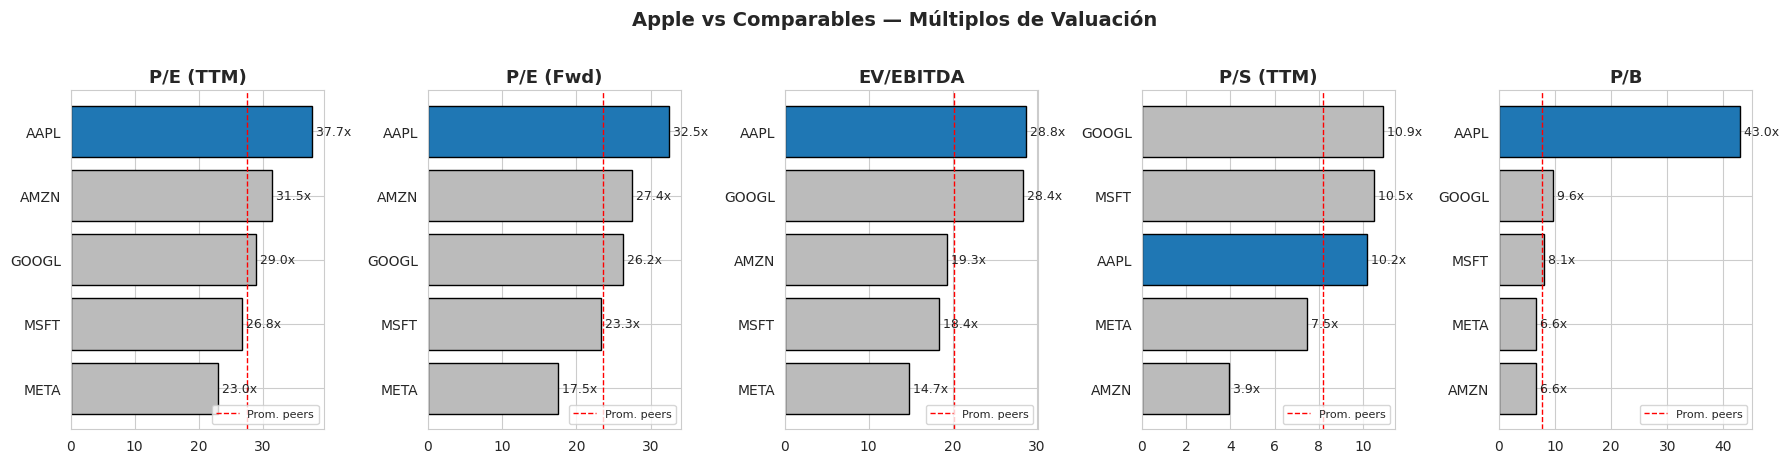

In [140]:
# Visualización: Apple vs pares en los 5 múltiplos clave
metricas = ['P/E (TTM)', 'P/E (Fwd)', 'EV/EBITDA', 'P/S (TTM)', 'P/B']
fig, axes = plt.subplots(1, 5, figsize=(18, 4.5))

for ax, m in zip(axes, metricas):
    serie = df_mult.loc[[TICKER] + PEERS, m].dropna().sort_values()
    colors = ['#1f77b4' if t == TICKER else '#bbbbbb' for t in serie.index]
    ax.barh(serie.index, serie.values, color=colors, edgecolor='black')
    ax.set_title(m)
    ax.axvline(serie.drop(TICKER, errors='ignore').mean(), color='red', ls='--', lw=1, label='Prom. peers')
    for i, v in enumerate(serie.values):
        ax.text(v, i, f' {v:.1f}x', va='center', fontsize=9)
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Apple vs Comparables — Múltiplos de Valuación', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Cómo leer estos gráficos:**

- Si Apple aparece **a la derecha** del promedio → cotiza con **prima** vs pares.
- Si aparece **a la izquierda** → cotiza con **descuento**.
- Una prima se justifica si Apple tiene mejor crecimiento esperado, márgenes más altos, ROE superior o ventajas competitivas durables (marca, ecosistema, switching costs).

---
## 💳 3. Costo de la Deuda (Kd) y Tasa Impositiva Efectiva

$K_d$ es la tasa que Apple paga **hoy** por endeudarse. Va después de impuestos $K_d(1-T)$ porque los intereses son deducibles del impuesto a las ganancias → **escudo fiscal**.

### Método utilizado — Synthetic (Rf + default spread)

$$ K_d = R_f + \text{Default Spread}_{rating} $$

Apple tiene rating de **máxima calidad crediticia: Aa1/Aaa (Moody's) y AA+ (S&P)**. Para el spread sobre Treasuries usamos el valor que el propio modelo de Damodaran fija para el rating **Aa1** en `ERPApril26_1.xlsx` (**26 bps**), consistente con una empresa de la calidad de Apple.

> **Nota metodológica:** descartamos el cálculo contable (Interest Expense / Deuda promedio) porque (1) refleja deuda emitida con tasas distintas a las actuales y (2) lo que importa para descontar flujos futuros es el **costo marginal de fondeo HOY**. Damodaran recomienda explícitamente este enfoque en *Investment Valuation*.

### Tasa Impositiva Efectiva

$$ T_{efectiva} = \frac{\text{Income Tax Expense}}{\text{Earnings Before Tax}} $$

Usamos la **efectiva** (no la marginal) porque captura beneficios fiscales reales — algo en lo que Apple es famosa por optimizar.

In [141]:
# Estados financieros de Apple (anuales)
income     = apple.financials
balance    = apple.balance_sheet
cashflow   = apple.cashflow

def get_row(df, candidates):
    """Busca la primera fila cuyo nombre matchee alguno de los candidatos."""
    for cand in candidates:
        for idx in df.index:
            if cand.lower() in idx.lower():
                return df.loc[idx]
    return None

pretax     = get_row(income, ['Pretax Income', 'Income Before Tax', 'Earnings Before Tax'])
tax_exp    = get_row(income, ['Tax Provision', 'Income Tax Expense'])
total_debt = get_row(balance, ['Total Debt'])

# Si no encuentra "Total Debt", lo construye sumando largo + corto plazo
if total_debt is None:
    long_d  = get_row(balance, ['Long Term Debt'])
    short_d = get_row(balance, ['Current Debt', 'Short Long Term Debt', 'Short Term Debt'])
    total_debt = (long_d.fillna(0) if long_d is not None else 0) + \
                 (short_d.fillna(0) if short_d is not None else 0)

print('--- Última fecha reportada ---')
print(income.columns[0].date())
print()
print(f'Earnings Before Tax     : {pretax.iloc[0]/1e9:>8,.2f} B')
print(f'Income Tax Provision    : {tax_exp.iloc[0]/1e9:>8,.2f} B')
print(f'Total Debt              : {total_debt.iloc[0]/1e9:>8,.2f} B')

--- Última fecha reportada ---
2025-09-30

Earnings Before Tax     :   132.73 B
Income Tax Provision    :    20.72 B
Total Debt              :    98.66 B


In [142]:
# === Costo de la Deuda Kd (método synthetic: Rf + default spread por rating) ===
# Rf y el spread vienen de la celda de PARÁMETROS (snapshot Damodaran abr-26),
# de modo que haya UNA sola fuente de verdad para estas tasas.
kd_market = RF_TREASURY_10Y + APPLE_SPREAD

print(f'Snapshot Damodaran               : {DAMODARAN_SNAPSHOT}')
print(f'Risk-free rate (US Treasury 10Y) : {RF_TREASURY_10Y*100:.2f}%')
print(f'Rating crediticio de Apple       : {APPLE_RATING}')
print(f'Default spread aplicado (Aa1)     : {APPLE_SPREAD*100:.2f}%  (Damodaran abr-26)')
print(f'\nKd (de mercado, synthetic) = Rf + spread = {kd_market*100:.2f}%')

# Chequeo informativo del drift de Rf vs snapshot (NO se usa en cálculos)
try:
    tnx_today = yf.Ticker('^TNX').history(period='5d')['Close'].iloc[-1] / 100
    drift_bps = (tnx_today - RF_TREASURY_10Y) * 10000
    print(f'\nℹ️  Rf hoy (^TNX, informativo) : {tnx_today*100:.2f}%  ({drift_bps:+.0f} bps vs snapshot)')
    print('   El modelo se queda con el snapshot para garantizar reproducibilidad.')
except Exception:
    pass

Snapshot Damodaran               : April 2026
Risk-free rate (US Treasury 10Y) : 4.32%
Rating crediticio de Apple       : Aa1 / Aaa (Moody's) · AA+ (S&P)
Default spread aplicado (Aa1)     : 0.26%  (Damodaran abr-26)

Kd (de mercado, synthetic) = Rf + spread = 4.58%

ℹ️  Rf hoy (^TNX, informativo) : 4.45%  (+13 bps vs snapshot)
   El modelo se queda con el snapshot para garantizar reproducibilidad.


In [143]:
# === Tasa impositiva efectiva ===
tax_rate_efectiva = abs(tax_exp.iloc[0] / pretax.iloc[0])

# Promedio histórico (más estable)
tax_rates_historicos = (tax_exp / pretax).dropna().abs()
tax_rates_historicos = tax_rates_historicos[(tax_rates_historicos > 0) & (tax_rates_historicos < 1)]
tax_rate_promedio = tax_rates_historicos.mean()

print(f'Tasa impositiva efectiva (último año)  : {tax_rate_efectiva*100:.2f}%')
print(f'Tasa impositiva efectiva (prom. {len(tax_rates_historicos)}A): {tax_rate_promedio*100:.2f}%')
print(f'\nTasas impositivas año a año:')
print((tax_rates_historicos*100).round(2).astype(str) + '%')

Tasa impositiva efectiva (último año)  : 15.61%
Tasa impositiva efectiva (prom. 4A): 17.66%

Tasas impositivas año a año:
2025-09-30    15.61%
2024-09-30    24.09%
2023-09-30    14.72%
2022-09-30     16.2%
dtype: object


✓ Kd seleccionado (de mercado)          : 4.58%
✓ Tax rate seleccionada (prom. histórico): 17.66%
✓ Kd después de impuestos = Kd·(1-T)    : 3.77%


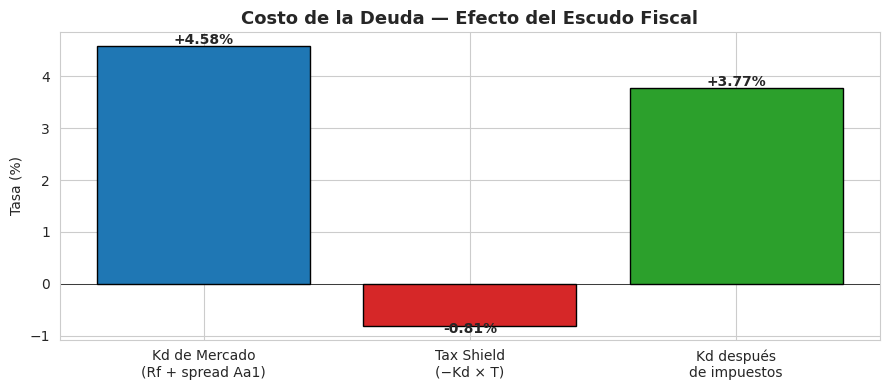

In [144]:
# === Decisión final: Kd y Tax rate definitivos ===
KD = kd_market
TAX_RATE = tax_rate_promedio

print(f'✓ Kd seleccionado (de mercado)          : {KD*100:.2f}%')
print(f'✓ Tax rate seleccionada (prom. histórico): {TAX_RATE*100:.2f}%')
print(f'✓ Kd después de impuestos = Kd·(1-T)    : {KD*(1-TAX_RATE)*100:.2f}%')

# Visualización: Kd pre-tax → Tax shield → Kd post-tax
fig, ax = plt.subplots(figsize=(9, 4))
metodos = ['Kd de Mercado\n(Rf + spread Aa1)', 'Tax Shield\n(−Kd × T)', 'Kd después\nde impuestos']
tax_shield = KD * TAX_RATE
valores = [KD*100, -tax_shield*100, KD*(1-TAX_RATE)*100]
colors = ['#1f77b4', '#d62728', '#2ca02c']
bars = ax.bar(metodos, valores, color=colors, edgecolor='black')
for b, v in zip(bars, valores):
    offset = 0.05 if v >= 0 else -0.15
    ax.text(b.get_x() + b.get_width()/2, v + offset, f'{v:+.2f}%',
            ha='center', fontweight='bold')
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Tasa (%)')
ax.set_title('Costo de la Deuda — Efecto del Escudo Fiscal', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📈 4. CAPM — Beta, Beta Desapalancado y Costo del Accionista (Ke)

$$ K_e = R_f + \beta \cdot (R_m - R_f) $$

- $R_f$ = tasa libre de riesgo (Treasury 10Y)
- $R_m - R_f$ = **Equity Risk Premium (ERP)** = prima por encima de lo libre de riesgo
- $\beta$ = sensibilidad de la acción a movimientos del mercado

### Cómo estimamos Beta — Regresión OLS

$$ R_{AAPL,t} - R_{f,t} = \alpha + \beta \cdot (R_{m,t} - R_{f,t}) + \varepsilon_t $$

Con 5 años de datos mensuales (60 obs — estándar Bloomberg).

In [145]:
# Descarga de precios mensuales (5 años)
data = yf.download(
    [TICKER, BENCHMARK],
    start=START_DATE, end=END_DATE,
    interval='1mo', auto_adjust=True, progress=False
)['Close']

data.columns = ['AAPL', 'SP500']
data = data.dropna()
returns = data.pct_change().dropna()

print(f'Observaciones mensuales : {len(returns)}')
print(f'Período                 : {returns.index[0].date()} → {returns.index[-1].date()}')
returns.head()

Observaciones mensuales : 59
Período                 : 2021-07-01 → 2026-05-01


,AAPL,SP500
Date,,
2021-07-01,0.064982,0.022748
2021-08-01,0.040930,0.028990
2021-09-01,-0.066640,-0.047569
2021-10-01,0.058657,0.069144
2021-11-01,0.103472,-0.008334


In [146]:
# Regresión OLS: AAPL ~ S&P 500
X = sm.add_constant(returns['SP500'])
y = returns['AAPL']

modelo = sm.OLS(y, X).fit()
beta_levered  = modelo.params['SP500']
alpha_mensual = modelo.params['const']
r_squared     = modelo.rsquared

print(modelo.summary().tables[1])
print()
print(f'Beta apalancado (β_L)  : {beta_levered:.4f}')
print(f'Alpha mensual (α)      : {alpha_mensual:.4%}')
print(f'R²                     : {r_squared:.4f}  → {r_squared*100:.1f}% de la varianza de AAPL la explica el mercado')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0054      0.007      0.774      0.442      -0.009       0.019
SP500          1.0837      0.148      7.326      0.000       0.788       1.380

Beta apalancado (β_L)  : 1.0837
Alpha mensual (α)      : 0.5367%
R²                     : 0.4849  → 48.5% de la varianza de AAPL la explica el mercado


In [147]:
# === Ajustes Blume y Vasicek al beta crudo ===
# Blume:   β_adj = 0.67·β_raw + 0.33·1.0   (reversión a la media, estándar Bloomberg)
# Vasicek: pondera β_raw y β_mercado=1 según la PRECISIÓN de la estimación (error estándar)

beta_blume = 0.67 * beta_levered + 0.33 * 1.0

se_beta   = modelo.bse['SP500']
var_self  = se_beta**2
var_cross = 0.10**2          # varianza típica cross-section de betas (Damodaran)
w_self    = var_cross / (var_self + var_cross)
beta_vasicek = w_self * beta_levered + (1 - w_self) * 1.0

betas_comp = pd.DataFrame({
    'Método':    ['β crudo (OLS 5Y mensual)', 'β Blume (0.67/0.33)',
                  'β Vasicek', 'β yfinance (referencia)'],
    'β':         [beta_levered, beta_blume, beta_vasicek, info.get('beta')],
})
betas_comp['Ke (CAPM)'] = betas_comp['β'].apply(
    lambda b: RF + b * ERP if b is not None else None
)
betas_comp['β']         = betas_comp['β'].round(3)
betas_comp['Ke (CAPM)'] = betas_comp['Ke (CAPM)'].apply(
    lambda x: f'{x*100:.2f}%' if x is not None else '—'
)
display(betas_comp)

# Decisión metodológica: usamos β Blume como β principal (corrige el sesgo de
# estimación de la regresión cruda y es el estándar de Bloomberg).
BETA_USADO = beta_blume
KE = RF + BETA_USADO * ERP

print(f'\n>>> β seleccionado (Blume) : {BETA_USADO:.3f}')
print(f'>>> Ke = {RF*100:.2f}% + {BETA_USADO:.3f} × {ERP*100:.2f}% = {KE*100:.2f}%')

,Método,β,Ke (CAPM)
0,β crudo (OLS 5Y mensual),1.084,9.49%
1,β Blume (0.67/0.33),1.056,9.36%
2,β Vasicek,1.026,9.22%
3,β yfinance (referencia),1.065,9.40%



>>> β seleccionado (Blume) : 1.056
>>> Ke = 4.32% + 1.056 × 4.77% = 9.36%


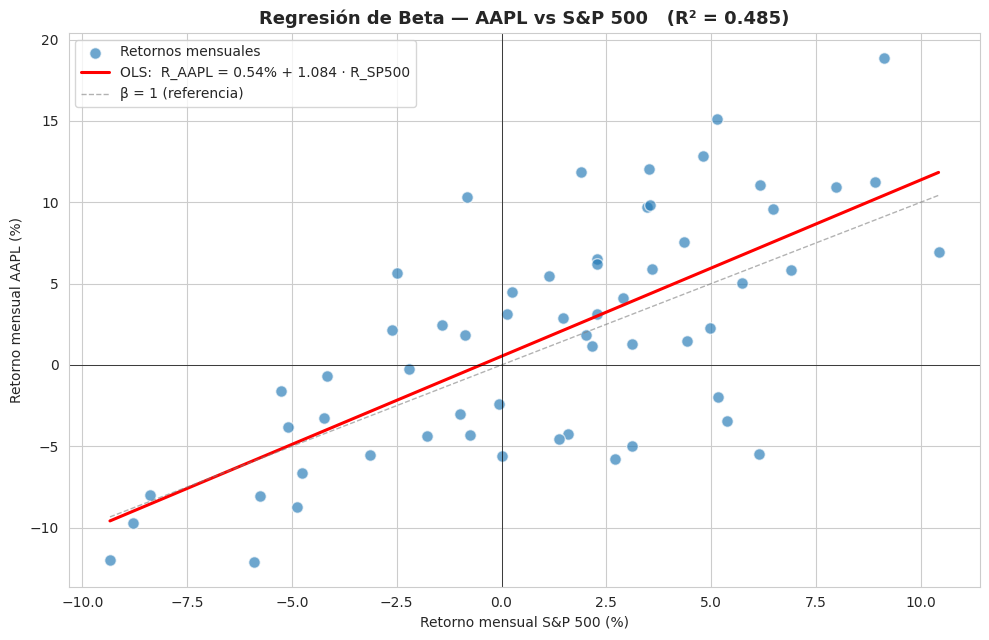

In [148]:
# Visualización: scatter + recta de regresión
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(returns['SP500']*100, returns['AAPL']*100, alpha=0.65, s=70,
           color='#1f77b4', edgecolor='white', linewidth=1, label='Retornos mensuales')

x_line = np.linspace(returns['SP500'].min(), returns['SP500'].max(), 100)
y_line = alpha_mensual + beta_levered * x_line
ax.plot(x_line*100, y_line*100, color='red', lw=2.2,
        label=f'OLS:  R_AAPL = {alpha_mensual*100:.2f}% + {beta_levered:.3f} · R_SP500')
ax.plot(x_line*100, x_line*100, color='gray', ls='--', lw=1, alpha=0.6, label='β = 1 (referencia)')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Retorno mensual S&P 500 (%)')
ax.set_ylabel('Retorno mensual AAPL (%)')
ax.set_title(f'Regresión de Beta — AAPL vs S&P 500   (R² = {r_squared:.3f})', fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

### Beta desapalancado (Hamada) — chequeo de consistencia

$$ \beta_U = \frac{\beta_L}{1 + (1-T) \cdot \frac{D}{E}} $$

El beta de la regresión ($\beta_L$) ya refleja el riesgo del *equity* tal como cotiza Apple hoy, **con su estructura de capital actual**. Como Apple tiene una deuda mínima frente a su capitalización (D/E ≈ 2%), desapalancar y volver a reapalancar el beta a la **misma** estructura no cambia el número en la práctica.

Por eso calculamos $\beta_U$ **solo como chequeo de consistencia** (confirma que el leverage no está inflando nuestro beta). Para el CAPM seguimos usando el $\beta_L$ ajustado por Blume y **no reapalancamos**, porque valuamos a la estructura de capital vigente.

In [149]:
# Beta desapalancado (chequeo de consistencia)
mkt_cap      = info.get('marketCap')
total_debt_v = total_debt.iloc[0]
de_ratio     = total_debt_v / mkt_cap

beta_unlevered = beta_levered / (1 + (1 - TAX_RATE) * de_ratio)

print(f'Market Cap (E)          : USD {mkt_cap/1e9:>8,.1f} B')
print(f'Total Debt (D)          : USD {total_debt_v/1e9:>8,.1f} B')
print(f'D/E ratio               : {de_ratio:.4f}  ({de_ratio*100:.2f}%)')
print(f'Tax rate                : {TAX_RATE*100:.2f}%')
print(f'\nBeta apalancado (β_L)   : {beta_levered:.4f}')
print(f'Beta desapalancado (β_U): {beta_unlevered:.4f}')
print(f'\nComo D/E ≈ {de_ratio*100:.1f}%, β_L ≈ β_U: el leverage casi no afecta el beta.')
print('No reapalancamos → para el Ke usamos β_L ajustado por Blume, a la estructura de capital actual.')

Market Cap (E)          : USD  4,583.3 B
Total Debt (D)          : USD     98.7 B
D/E ratio               : 0.0215  (2.15%)
Tax rate                : 17.66%

Beta apalancado (β_L)   : 1.0837
Beta desapalancado (β_U): 1.0649

Como D/E ≈ 2.2%, β_L ≈ β_U: el leverage casi no afecta el beta.
No reapalancamos → para el Ke usamos β_L ajustado por Blume, a la estructura de capital actual.


In [150]:
# Sanity check vs yfinance
yf_beta = info.get('beta')
comparacion_beta = pd.DataFrame({
    'Fuente': ['Regresión OLS propia (5Y mensual)', 'yfinance .info', 'Beta desapalancado (Hamada)'],
    'Beta':   [round(beta_levered, 3), round(yf_beta, 3) if yf_beta else None, round(beta_unlevered, 3)],
    'Comentario': [
        'Calculada en este notebook con S&P 500',
        'Reportado por Yahoo Finance (ventana puede diferir)',
        'Chequeo: removido el leverage (no se usa en el WACC)'
    ]
})
comparacion_beta

,Fuente,Beta,Comentario
0,Regresión OLS propia (5Y mensual),1.084,Calculada en este notebook con S&P 500
1,yfinance .info,1.065,Reportado por Yahoo Finance (ventana puede dif...
2,Beta desapalancado (Hamada),1.065,Chequeo: removido el leverage (no se usa en el...


### Costo del accionista (Ke) — CAPM

$$ K_e = R_f + \beta_{\text{Blume}} \cdot ERP $$

| Input | Valor | Fuente |
|---|---|---|
| $R_f$ | 4.32% | US Treasury 10Y, abril 2026 (Damodaran, `ERPApril26_1.xlsx`) |
| $ERP$ | 4.77% | Implied ERP forward-looking, Damodaran abril 2026 (`ERPApril26_1.xlsx`) |
| $\beta$ | β Blume ajustado | Regresión propia AAPL vs S&P 500 (5Y mensual), corregida por Blume |

> **¿Por qué β ajustado por Blume y no el crudo de la regresión?** El beta de una sola regresión tiene error de estimación y tiende a revertir hacia 1 con el tiempo. El ajuste de Blume ($0.67\,\beta + 0.33$) corrige ese sesgo y es el estándar que reporta Bloomberg. Por eso el $K_e$ que usamos **parte del β Blume, no del β crudo** — y así el número del texto coincide con el del código.

> **¿Por qué ERP implícito (forward-looking) y no histórico?** El histórico (~5.5% para US 1928-actual) refleja lo que pasó. El implícito lo deriva Damodaran resolviendo "qué ERP iguala el precio actual del S&P 500 con el VAN de sus flujos esperados", o sea **lo que el mercado descuenta hacia adelante** — que es lo relevante para una valuación.

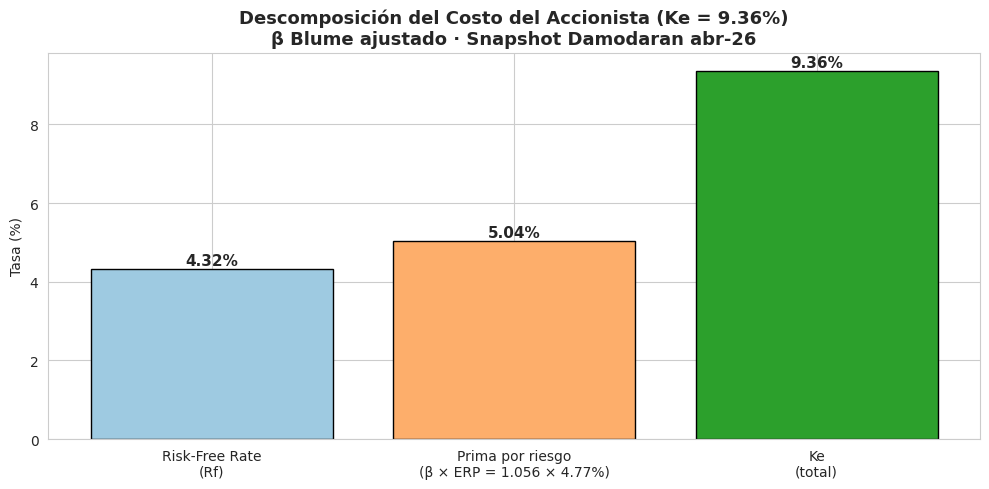

Rf (snapshot Damodaran abr-26) : 4.32%
ERP (Damodaran abr-26)         : 4.77%
β Blume (BETA_USADO)           : 1.056
>>> Ke definitivo              : 9.36%


In [151]:
# === Ke definitivo + descomposición visual ===
# Recalcula KE aquí mismo para que sea robusto: no asume que esté bien
# desde otra celda. La fuente de verdad de KE es esta celda.

KE = RF + BETA_USADO * ERP   # ← cálculo explícito, no asumir nada

# Sanity check antes de graficar
suma = RF*100 + BETA_USADO*ERP*100
assert abs(suma - KE*100) < 0.001, f'Inconsistencia: {suma:.4f} ≠ {KE*100:.4f}'

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
componentes = [
    'Risk-Free Rate\n(Rf)',
    f'Prima por riesgo\n(β × ERP = {BETA_USADO:.3f} × {ERP*100:.2f}%)',
    'Ke\n(total)'
]
valores = [RF*100, BETA_USADO*ERP*100, KE*100]
colors  = ['#9ecae1', '#fdae6b', '#2ca02c']
ax.bar(componentes, valores, color=colors, edgecolor='black')
for i, v in enumerate(valores):
    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Tasa (%)')
ax.set_title(
    f'Descomposición del Costo del Accionista (Ke = {KE*100:.2f}%)\n'
    f'β Blume ajustado · Snapshot Damodaran abr-26',
    fontweight='bold'
)
plt.tight_layout(); plt.show()

# Confirmación
print(f'Rf (snapshot Damodaran abr-26) : {RF*100:.2f}%')
print(f'ERP (Damodaran abr-26)         : {ERP*100:.2f}%')
print(f'β Blume (BETA_USADO)           : {BETA_USADO:.3f}')
print(f'>>> Ke definitivo              : {KE*100:.2f}%')

---
## ⚖️ 5. WACC — Cálculo Final

$$ \text{WACC} = \frac{E}{V} \cdot K_e + \frac{D}{V} \cdot K_d \cdot (1-T) \quad \text{con } V = E + D $$

Pesos a **valor de mercado**, no contable.

In [152]:
E = mkt_cap
D = total_debt_v
V = E + D

w_E = E / V
w_D = D / V

WACC = w_E * KE + w_D * KD * (1 - TAX_RATE)

tabla_wacc = pd.DataFrame({
    'Componente': ['Equity (E)', 'Deuda (D)', 'Total (V = E+D)',
                   'Peso Equity (E/V)', 'Peso Deuda (D/V)',
                   'Ke', 'Kd', 'Tax rate (T)', 'Kd · (1-T)',
                   'WACC'],
    'Valor': [
        f'USD {E/1e9:,.1f} B',
        f'USD {D/1e9:,.1f} B',
        f'USD {V/1e9:,.1f} B',
        f'{w_E*100:.2f}%',
        f'{w_D*100:.2f}%',
        f'{KE*100:.2f}%',
        f'{KD*100:.2f}%',
        f'{TAX_RATE*100:.2f}%',
        f'{KD*(1-TAX_RATE)*100:.2f}%',
        f'{WACC*100:.2f}%'
    ]
})
tabla_wacc

,Componente,Valor
0,Equity (E),"USD 4,583.3 B"
1,Deuda (D),USD 98.7 B
2,Total (V = E+D),"USD 4,682.0 B"
3,Peso Equity (E/V),97.89%
4,Peso Deuda (D/V),2.11%
5,Ke,9.36%
6,Kd,4.58%
7,Tax rate (T),17.66%
8,Kd · (1-T),3.77%
9,WACC,9.24%


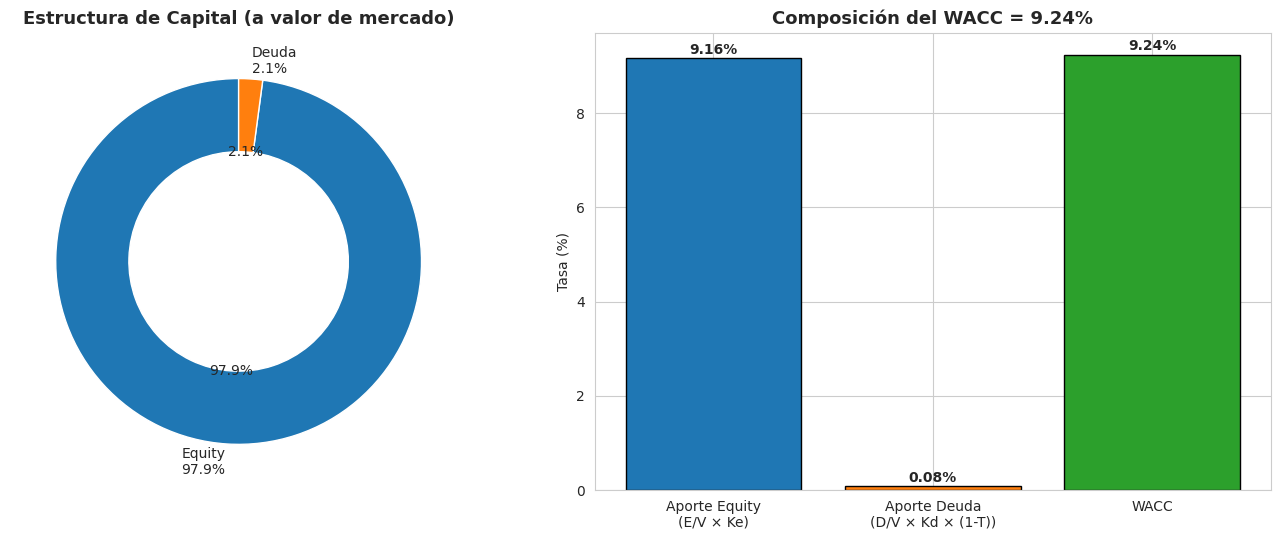

In [153]:
# Visualización: estructura de capital + composición del WACC
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sizes = [w_E*100, w_D*100]
labels = [f'Equity\n{w_E*100:.1f}%', f'Deuda\n{w_D*100:.1f}%']
colors_pie = ['#1f77b4', '#ff7f0e']
axes[0].pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(width=0.4, edgecolor='white'))
axes[0].set_title('Estructura de Capital (a valor de mercado)', fontweight='bold')

contrib_E = w_E * KE * 100
contrib_D = w_D * KD * (1-TAX_RATE) * 100
axes[1].bar(['Aporte Equity\n(E/V × Ke)', 'Aporte Deuda\n(D/V × Kd × (1-T))', 'WACC'],
            [contrib_E, contrib_D, WACC*100],
            color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
for i, v in enumerate([contrib_E, contrib_D, WACC*100]):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')
axes[1].set_ylabel('Tasa (%)')
axes[1].set_title(f'Composición del WACC = {WACC*100:.2f}%', fontweight='bold')

plt.tight_layout()
plt.show()

### 🌡️ Sensibilidad del WACC ante β y ERP

Las dos variables que más mueven el WACC para Apple (95% equity) son **Beta** y **ERP**. Mostramos un rango.

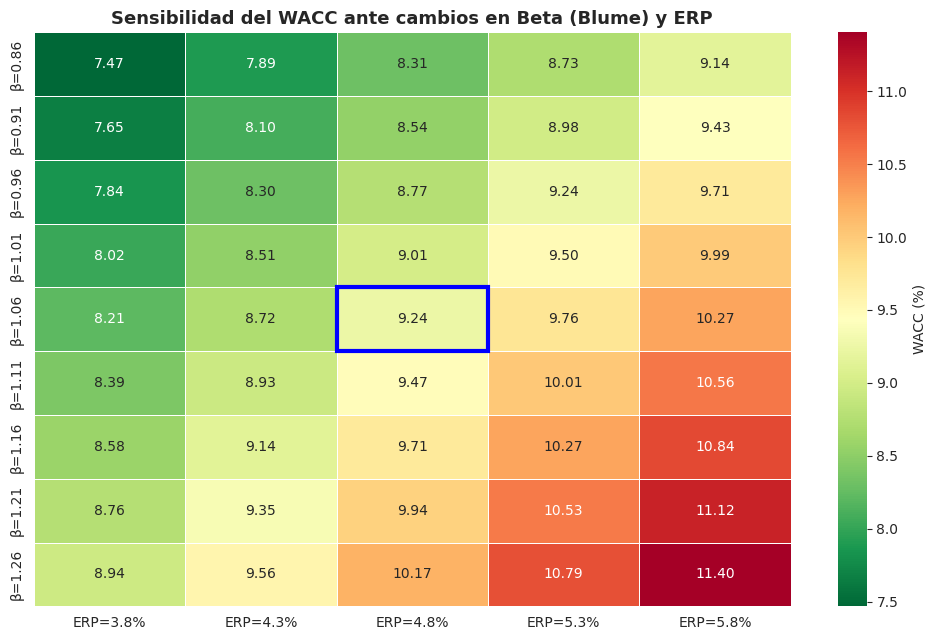


✓ Caso base: β=1.06 (Blume), ERP=4.8% → WACC = 9.24% (recuadro azul)


In [154]:
# === Sensibilidad del WACC ante cambios en Beta (Blume) y ERP ===

# Offsets alrededor del caso base
beta_offsets = np.arange(-0.20, 0.21, 0.05)
erp_offsets  = np.arange(-0.010, 0.0101, 0.005)

# Grids centrados exactamente en los valores reales usados en el WACC
betas_grid = BETA_USADO + beta_offsets
erps_grid  = ERP + erp_offsets

matriz_wacc = np.zeros((len(betas_grid), len(erps_grid)))

for i, b in enumerate(betas_grid):
    for j, e in enumerate(erps_grid):
        ke_ij = RF + b * e
        wacc_ij = w_E * ke_ij + w_D * KD * (1 - TAX_RATE)
        matriz_wacc[i, j] = wacc_ij * 100

# Índices del caso base exacto: centro de la matriz
i_base = len(betas_grid) // 2
j_base = len(erps_grid) // 2

# Forzamos la celda central a mostrar exactamente el WACC base real
# para evitar diferencias mínimas por redondeos
matriz_wacc[i_base, j_base] = WACC * 100

df_sens_wacc = pd.DataFrame(
    matriz_wacc,
    index=[f'β={b:.2f}' for b in betas_grid],
    columns=[f'ERP={e*100:.1f}%' for e in erps_grid]
)

fig, ax = plt.subplots(figsize=(10, 6.5))

sns.heatmap(
    df_sens_wacc,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    cbar_kws={'label': 'WACC (%)'},
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'fontsize': 10}
)

ax.set_title(
    'Sensibilidad del WACC ante cambios en Beta (Blume) y ERP',
    fontweight='bold'
)

# Recuadro azul en el caso base exacto
ax.add_patch(
    plt.Rectangle(
        (j_base, i_base),
        1,
        1,
        fill=False,
        edgecolor='blue',
        lw=3
    )
)

plt.tight_layout()
plt.show()

print(
    f'\n✓ Caso base: β={BETA_USADO:.2f} (Blume), '
    f'ERP={ERP*100:.1f}% → WACC = {WACC*100:.2f}% '
    f'(recuadro azul)'
)

### ✅ Cierre Parte 1

Tenemos el **WACC** listo para descontar los flujos. Pasamos a la valuación.

---
# 💰 PARTE 2 — Valuación por Flujos de Fondos Descontados (FFD)

Con el WACC ya construido (variable `WACC` en memoria), descontamos los FCF proyectados, calculamos el valor terminal por Gordon-Shapiro y llegamos al precio objetivo por acción.

### 🧠 La intuición del DCF en una frase

> *"Una empresa vale la suma del dinero que va a generar en el futuro, traído al presente con una tasa que refleja su riesgo."*

Como una empresa vive infinitos años, partimos el cálculo en dos:

1. **Período explícito (2026-2030):** los 5 años con proyecciones detalladas (cátedra).
2. **Período de continuidad (2031 → ∞):** lo capturamos en un solo número, el **Valor Terminal**, asumiendo que de ahí en adelante la empresa crece a una tasa estable $g$ por toda la eternidad.

$$ \boxed{\text{Enterprise Value} = \underbrace{\sum_{t=1}^{5} \frac{FCF_t}{(1+WACC)^t}}_{\text{VP de los 5 años}} + \underbrace{\frac{TV_{2030}}{(1+WACC)^5}}_{\text{VP del valor terminal}}} $$

---

## 📥 6. Inputs adicionales para la Parte 2

Datos del mercado y FCFs proyectados. El WACC, KE, KD, etc. ya están calculados en la Parte 1.

In [155]:
# === Datos de mercado para el puente EV → Equity ===
# Precio, acciones en circulación, caja/inversiones líquidas y deuda (snapshot del día de corrida).
# 'apple', 'info' y 'get_row' ya están definidos en la Parte 1; al usar 'Ejecutar todo' están disponibles.
apple   = yf.Ticker(TICKER)
info    = apple.info
balance = apple.balance_sheet

total_debt = get_row(balance, ['Total Debt'])
if total_debt is None:
    long_d  = get_row(balance, ['Long Term Debt'])
    short_d = get_row(balance, ['Current Debt', 'Short Long Term Debt', 'Short Term Debt'])
    total_debt = (long_d.fillna(0) if long_d is not None else 0) + \
                 (short_d.fillna(0) if short_d is not None else 0)

# === Datos de mercado ===
PRECIO_ACTUAL = info.get('currentPrice') or info.get('regularMarketPrice')
SHARES_OUT    = info.get('sharesOutstanding')
MKT_CAP       = info.get('marketCap')

# === Caja + inversiones líquidas — captura las TRES líneas, no solo cash ===
def safe(s):
    """Devuelve 0.0 si la serie es None o NaN."""
    if s is None: return 0.0
    v = s.iloc[0]
    return 0.0 if pd.isna(v) else float(v)

cash_eq        = get_row(balance, ['Cash And Cash Equivalents'])
st_investments = get_row(balance, ['Other Short Term Investments',
                                    'Short Term Investments',
                                    'Current Marketable Securities'])
lt_investments = get_row(balance, ['Available For Sale Securities',
                                    'Investments And Advances',
                                    'Investmentin Financial Assets',
                                    'Long Term Investments',
                                    'Other Investments'])

CASH_EQ_M       = safe(cash_eq)        / 1e6
ST_INV_M        = safe(st_investments) / 1e6
LT_INV_M        = safe(lt_investments) / 1e6
TOTAL_LIQUIDS_M = CASH_EQ_M + ST_INV_M + LT_INV_M

TOTAL_DEBT_M = total_debt.iloc[0] / 1e6
NET_DEBT_M   = TOTAL_DEBT_M - TOTAL_LIQUIDS_M
CASH_M       = TOTAL_LIQUIDS_M   # alias para compatibilidad

print(f'Precio actual de la acción : USD {PRECIO_ACTUAL:,.2f}')
print(f'Acciones en circulación    : {SHARES_OUT/1e9:,.2f} B  ({SHARES_OUT:,})')
print(f'Market Cap                 : USD {MKT_CAP/1e9:,.1f} B')
print()
print('--- Composición de activos líquidos ---')
print(f'  Cash & equivalents       : USD {CASH_EQ_M/1000:>7,.1f} B')
print(f'  Short-term investments   : USD {ST_INV_M/1000:>7,.1f} B')
print(f'  Long-term investments    : USD {LT_INV_M/1000:>7,.1f} B')
print(f'  TOTAL líquidos           : USD {TOTAL_LIQUIDS_M/1000:>7,.1f} B')
print()
print(f'Deuda total                : USD {TOTAL_DEBT_M/1000:>7,.1f} B')
print(f'(−) Activos líquidos       : USD {TOTAL_LIQUIDS_M/1000:>7,.1f} B')
print(f'                             {"─"*22}')
print(f'NET DEBT                   : USD {NET_DEBT_M/1000:>+7,.1f} B')

if NET_DEBT_M < 0:
    print(f'\n💡 Apple tiene CAJA NETA POSITIVA de USD {-NET_DEBT_M/1000:,.1f} B')
    print('   → se SUMA al equity value en el bridge EV → Equity.')
else:
    print(f'\n⚠️  Net Debt resultó positiva (USD {NET_DEBT_M/1000:.1f} B).')
    print('   Verificá que yfinance esté devolviendo las líneas de marketable securities.')

Precio actual de la acción : USD 312.06
Acciones en circulación    : 14.69 B  (14,687,356,000)
Market Cap                 : USD 4,583.3 B

--- Composición de activos líquidos ---
  Cash & equivalents       : USD    35.9 B
  Short-term investments   : USD    18.8 B
  Long-term investments    : USD    77.7 B
  TOTAL líquidos           : USD   132.4 B

Deuda total                : USD    98.7 B
(−) Activos líquidos       : USD   132.4 B
                             ──────────────────────
NET DEBT                   : USD   -33.8 B

💡 Apple tiene CAJA NETA POSITIVA de USD 33.8 B
   → se SUMA al equity value en el bridge EV → Equity.


### FCFs Proyectados

Los fondos son los provistos por la cátedra. El WACC, KE, KD, etc. ya están calculados en la Parte 1.

In [156]:
# === FCF PROYECTADOS (en millones de USD) — provistos por la cátedra ===
fcf_data = pd.DataFrame({
    'Año':           [2026, 2027, 2028, 2029, 2030],
    'FCFF_USD_M':    [153_206.56, 167_393.48, 182_894.12, 199_830.12, 218_334.39],
    'Crecimiento':   [0.0926, 0.0926, 0.0926, 0.0926, 0.0926],
}).set_index('Año')

FCF_ULTIMO_CONOCIDO  = 140_222

# Nota: la celda 'Valor actual terminal' del Excel de la cátedra la interpretamos como el
# Valor Terminal AL CIERRE DE 2030 (sin descontar), consistente con un g implícito de ~3.4%
# (ver celda del Valor Terminal). Si la cátedra lo definió como valor presente, habría que
# ajustar la comparación; conviene confirmarlo con la cátedra.
TV_REFERENCIA_2030   = 3_857_497.98   # USD millones — TV al cierre de 2030 (Excel cátedra)

print('Flujos de Fondos Libres a la Firma (FCFF) — USD millones')
display(fcf_data.style.format({'FCFF_USD_M': '{:,.0f}', 'Crecimiento': '{:.2%}'}))
print(f'\nFCFF último año conocido (2025): USD {FCF_ULTIMO_CONOCIDO:,.0f} M')
print(f'Valor Terminal de referencia (Excel cátedra, cierre 2030): USD {TV_REFERENCIA_2030:,.0f} M')

Flujos de Fondos Libres a la Firma (FCFF) — USD millones


,FCFF_USD_M,Crecimiento
Año,,
2026,"153,207",9.26%
2027,"167,393",9.26%
2028,"182,894",9.26%
2029,"199,830",9.26%
2030,"218,334",9.26%



FCFF último año conocido (2025): USD 140,222 M
Valor Terminal de referencia (Excel cátedra, cierre 2030): USD 3,857,498 M


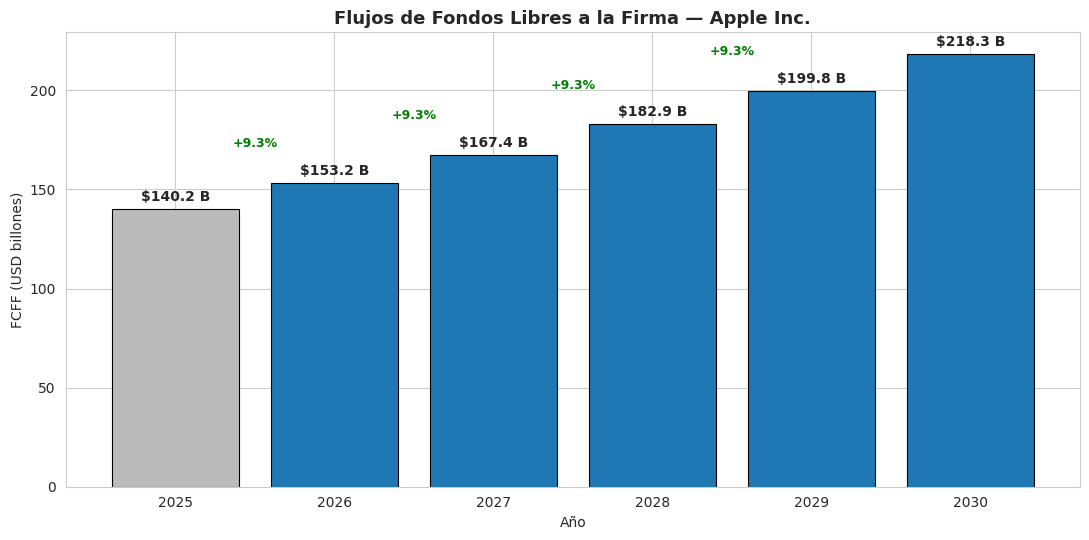

In [157]:
# Visualización de los FCF proyectados
fig, ax = plt.subplots(figsize=(11, 5.5))
años = [2025] + list(fcf_data.index)
fcfs = [FCF_ULTIMO_CONOCIDO] + list(fcf_data['FCFF_USD_M'])
colors_fcf = ['#bbbbbb'] + ['#1f77b4']*5

bars = ax.bar(años, [f/1000 for f in fcfs], color=colors_fcf, edgecolor='black', linewidth=0.8)
for b, f in zip(bars, fcfs):
    ax.text(b.get_x() + b.get_width()/2, f/1000 + 4, f'${f/1000:.1f} B',
            ha='center', fontweight='bold', fontsize=10)

for i in range(1, len(años)):
    g_yr = fcfs[i]/fcfs[i-1] - 1
    ax.annotate(f'+{g_yr*100:.1f}%',
                xy=((años[i-1]+años[i])/2, max(fcfs[i-1], fcfs[i])/1000 + 18),
                ha='center', color='green', fontweight='bold', fontsize=9)

ax.set_xlabel('Año')
ax.set_ylabel('FCFF (USD billones)')
ax.set_title('Flujos de Fondos Libres a la Firma — Apple Inc.', fontweight='bold')
ax.set_xticks(años)
plt.tight_layout()
plt.show()

### 🔎 6.b Análisis crítico de los flujos de la cátedra

Los flujos los proyectó la cátedra, pero un buen analista no los toma como dogma: chequea si la **tasa de crecimiento implícita** es razonable para una empresa del tamaño y madurez de Apple. Comparamos el CAGR de los flujos proyectados contra el crecimiento histórico real del FCF de Apple.

In [158]:
# CAGR implícito en los flujos proyectados por la cátedra (2025 → 2030)
cagr_catedra = (fcf_data['FCFF_USD_M'].iloc[-1] / FCF_ULTIMO_CONOCIDO) ** (1/5) - 1
print(f'CAGR implícito en los flujos de la cátedra (2025→2030): {cagr_catedra*100:.2f}%')

# Benchmark: CAGR histórico real del FCF de Apple (de los estados financieros)
try:
    cf_hist = apple.cashflow
    fcf_row = get_row(cf_hist, ['Free Cash Flow'])
    if fcf_row is not None:
        fcf_row = fcf_row.dropna().sort_index()
        n = len(fcf_row) - 1
        if n >= 1:
            cagr_hist = (fcf_row.iloc[-1] / fcf_row.iloc[0]) ** (1/n) - 1
            print(f'CAGR histórico real del FCF de Apple ({n+1} años)      : {cagr_hist*100:.2f}%')
            print(f'→ La cátedra proyecta crecer {(cagr_catedra-cagr_hist)*100:+.1f} p.p./año vs. el histórico reciente.')
        else:
            print('(Serie histórica de FCF demasiado corta para un CAGR.)')
    else:
        print('(No se pudo leer el FCF histórico desde yfinance para el benchmark.)')
except Exception as e:
    print(f'(Benchmark histórico no disponible: {e})')

print('\nLectura: las proyecciones asumen una aceleración del FCF (mix de Servicios de mayor margen')
print('+ ciclo de Apple Intelligence). Es un supuesto optimista pero no absurdo para Apple;')
print('si no se materializa, tanto el FCF como el precio objetivo se ajustan a la baja.')

CAGR implícito en los flujos de la cátedra (2025→2030): 9.26%
CAGR histórico real del FCF de Apple (4 años)      : -3.95%
→ La cátedra proyecta crecer +13.2 p.p./año vs. el histórico reciente.

Lectura: las proyecciones asumen una aceleración del FCF (mix de Servicios de mayor margen
+ ciclo de Apple Intelligence). Es un supuesto optimista pero no absurdo para Apple;
si no se materializa, tanto el FCF como el precio objetivo se ajustan a la baja.


---
## 💵 7. Descuento del Período Explícito (2026-2030)

Para cada año $t$:

$$ VP(FCF_t) = \frac{FCF_t}{(1 + WACC)^t} $$

Es el inverso de la capitalización compuesta — un dólar dentro de 5 años vale menos que un dólar hoy.

In [159]:
fcf_data['t']        = range(1, 6)
fcf_data['Discount'] = (1 + WACC) ** fcf_data['t']
fcf_data['VP_FCF_M'] = fcf_data['FCFF_USD_M'] / fcf_data['Discount']

PV_EXPLICITO = fcf_data['VP_FCF_M'].sum()

tabla_pv = fcf_data[['FCFF_USD_M', 't', 'Discount', 'VP_FCF_M']].copy()
tabla_pv.columns = ['FCFF (USD M)', 't', '(1+WACC)^t', 'VP (USD M)']
display(tabla_pv.style.format({
    'FCFF (USD M)': '{:,.0f}',
    '(1+WACC)^t':   '{:.4f}',
    'VP (USD M)':   '{:,.0f}'
}))

print(f'\n>>> VP del período explícito (2026-2030) = USD {PV_EXPLICITO:,.0f} M')
print(f'                                        ≈ USD {PV_EXPLICITO/1000:,.1f} B')

,FCFF (USD M),t,(1+WACC)^t,VP (USD M)
Año,,,,
2026,"153,207",1,1.0924,"140,248"
2027,"167,393",2,1.1933,"140,274"
2028,"182,894",3,1.3036,"140,299"
2029,"199,830",4,1.4241,"140,325"
2030,"218,334",5,1.5556,"140,351"



>>> VP del período explícito (2026-2030) = USD 701,497 M
                                        ≈ USD 701.5 B


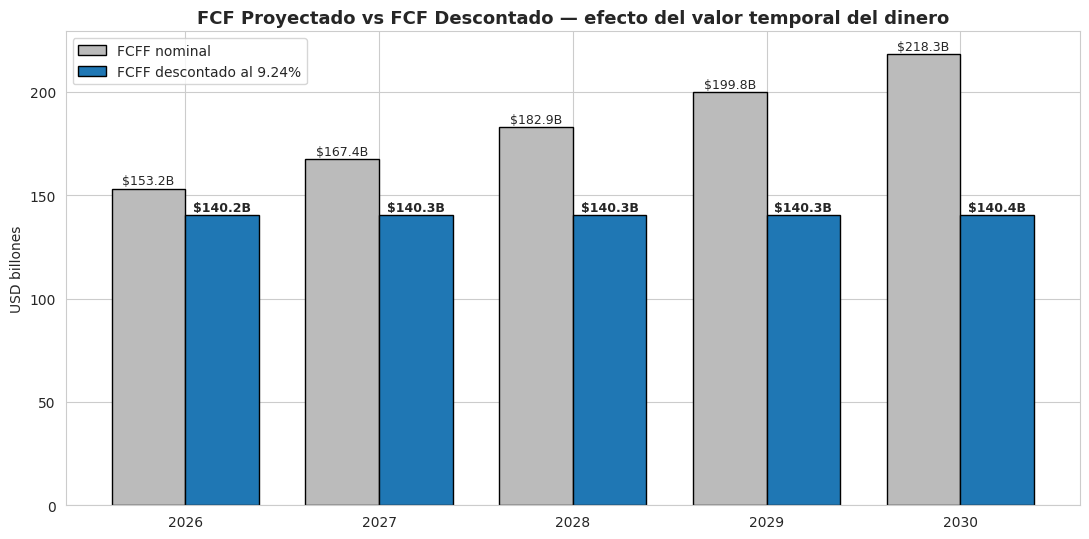

In [160]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(fcf_data))
width = 0.38

bars1 = ax.bar(x - width/2, fcf_data['FCFF_USD_M']/1000, width,
               label='FCFF nominal', color='#bbbbbb', edgecolor='black')
bars2 = ax.bar(x + width/2, fcf_data['VP_FCF_M']/1000, width,
               label=f'FCFF descontado al {WACC*100:.2f}%', color='#1f77b4', edgecolor='black')

for b in bars1:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
            f'${b.get_height():.1f}B', ha='center', fontsize=9)
for b in bars2:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
            f'${b.get_height():.1f}B', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(fcf_data.index)
ax.set_ylabel('USD billones')
ax.set_title('FCF Proyectado vs FCF Descontado — efecto del valor temporal del dinero',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

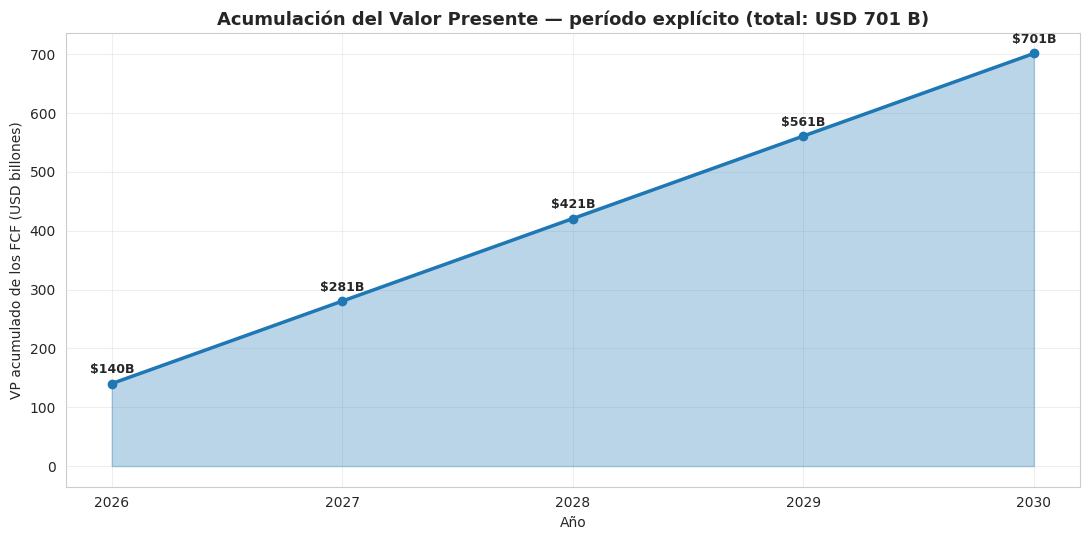

In [161]:
# === Area chart: acumulación del Valor Presente a lo largo del período explícito ===
acum_vp = np.cumsum(fcf_data['VP_FCF_M'].values) / 1000   # USD billones
años_ex = list(fcf_data.index)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.fill_between(años_ex, acum_vp, color='#1f77b4', alpha=0.30, zorder=1)
ax.plot(años_ex, acum_vp, color='#1f77b4', lw=2.5, marker='o', zorder=2)
for x, y in zip(años_ex, acum_vp):
    ax.text(x, y + acum_vp[-1]*0.025, f'${y:.0f}B', ha='center', fontweight='bold', fontsize=9)
ax.set_xlabel('Año')
ax.set_ylabel('VP acumulado de los FCF (USD billones)')
ax.set_title(f'Acumulación del Valor Presente — período explícito (total: USD {PV_EXPLICITO/1000:,.0f} B)',
             fontweight='bold')
ax.set_xticks(años_ex)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## ♾️ 8. Valor Terminal — Modelo de Gordon-Shapiro

A partir del año 6 asumimos un régimen de "estado estable": crece a $g$ constante perpetuamente.

$$ TV_{2030} = \frac{FCF_{2030} \cdot (1 + g)}{WACC - g} $$

### ⚠️ Las dos restricciones críticas sobre $g$

1. **$g < WACC$** (matemática): si no, la fórmula se rompe.
2. **$g \le$ crecimiento nominal de la economía**: ninguna empresa puede crecer más rápido que el PIB nominal por siempre — sería más grande que la economía entera.

| Referencia | Valor |
|---|---|
| Inflación objetivo Fed | 2.0% |
| Crecimiento real US (largo plazo) | ~2.0% |
| **PIB nominal US** | **~3.5-4.0%** |
| Risk-free rate (regla Damodaran: $g \le R_f$) | 4.32% |

**Caso base: $g = 3.0\%$** — entre la inflación objetivo y el PIB nominal. Conservador dado que Apple genera muchísima caja, pero respetando la regla de oro.

> 💡 *"3% reconoce que Apple es un negocio maduro de alta calidad, y simultáneamente respeta el principio de que ninguna empresa puede crecer más que la economía en el largo plazo."*

In [162]:
g = 0.030  # 3.0% — caso base

FCF_2030    = fcf_data.loc[2030, 'FCFF_USD_M']
FCF_2031    = FCF_2030 * (1 + g)
TV_2030     = FCF_2031 / (WACC - g)
PV_TV       = TV_2030 / (1 + WACC)**5

print(f'FCFF 2030                  : USD {FCF_2030:>12,.0f} M')
print(f'FCFF 2031 = FCFF_2030·(1+g): USD {FCF_2031:>12,.0f} M    (g = {g*100:.1f}%)')
print(f'WACC                       : {WACC*100:.2f}%')
print(f'WACC − g                   : {(WACC-g)*100:.2f}%')
print(f'\nTV al final de 2030       = FCFF_2031 / (WACC − g)')
print(f'                          = USD {FCF_2031:,.0f} / {WACC-g:.4f}')
print(f'                          = USD {TV_2030:,.0f} M')
print(f'                          ≈ USD {TV_2030/1e6:,.2f} TRILLONES')
print(f'\nVP del TV (descontado 5 años) = USD {PV_TV:,.0f} M')

# Sanity check vs TV cátedra
print(f'\n--- Comparación con TV del Excel cátedra ---')
print(f'TV Cátedra : USD {TV_REFERENCIA_2030:,.0f} M')
print(f'TV Calculado: USD {TV_2030:,.0f} M')
print(f'Diferencia : {(TV_2030/TV_REFERENCIA_2030 - 1)*100:+.1f}%')

# g implícito en el TV de la cátedra
g_implicito_catedra = (WACC * TV_REFERENCIA_2030 - FCF_2030) / (TV_REFERENCIA_2030 + FCF_2030)
print(f'\n💡 g implícito en TV cátedra (con WACC = {WACC*100:.2f}%): {g_implicito_catedra*100:.2f}%')

FCFF 2030                  : USD      218,334 M
FCFF 2031 = FCFF_2030·(1+g): USD      224,884 M    (g = 3.0%)
WACC                       : 9.24%
WACC − g                   : 6.24%

TV al final de 2030       = FCFF_2031 / (WACC − g)
                          = USD 224,884 / 0.0624
                          = USD 3,603,963 M
                          ≈ USD 3.60 TRILLONES

VP del TV (descontado 5 años) = USD 2,316,720 M

--- Comparación con TV del Excel cátedra ---
TV Cátedra : USD 3,857,498 M
TV Calculado: USD 3,603,963 M
Diferencia : -6.6%

💡 g implícito en TV cátedra (con WACC = 9.24%): 3.39%


In [163]:
# === Robustez del Valor Terminal: ¿qué múltiplo de salida implica? ===
# El TV de Gordon equivale a aplicar un múltiplo EV/FCFF de "salida" al FCFF de 2030.
exit_multiple = TV_2030 / FCF_2030
print(f'Múltiplo de salida implícito en el TV (TV_2030 / FCFF_2030): {exit_multiple:.1f}x')
ev_ebitda_hoy = info.get('enterpriseToEbitda')
if ev_ebitda_hoy:
    print(f'Referencia: Apple cotiza hoy a EV/EBITDA ≈ {ev_ebitda_hoy:.1f}x.')
print('\nLectura: un múltiplo de salida ~16-17x FCFF es razonable para un negocio maduro')
print('de alta calidad. Esto le da soporte de "sentido común" al Valor Terminal,')
print('más allá de que la fórmula de Gordon sea muy sensible a g y al WACC.')

Múltiplo de salida implícito en el TV (TV_2030 / FCFF_2030): 16.5x
Referencia: Apple cotiza hoy a EV/EBITDA ≈ 28.8x.

Lectura: un múltiplo de salida ~16-17x FCFF es razonable para un negocio maduro
de alta calidad. Esto le da soporte de "sentido común" al Valor Terminal,
más allá de que la fórmula de Gordon sea muy sensible a g y al WACC.


---
## 🏢 9. Enterprise Value (EV)

$$ EV = \underbrace{\sum_{t=1}^{5} \frac{FCF_t}{(1+WACC)^t}}_{\text{Período explícito}} + \underbrace{\frac{TV_{2030}}{(1+WACC)^5}}_{\text{Período de continuidad}} $$

In [164]:
EV = PV_EXPLICITO + PV_TV
peso_explicito = PV_EXPLICITO / EV
peso_terminal  = PV_TV / EV

print(f'VP Período explícito (2026-2030) : USD {PV_EXPLICITO:>13,.0f} M  ({peso_explicito*100:>5.1f}%)')
print(f'VP Valor Terminal                : USD {PV_TV:>13,.0f} M  ({peso_terminal*100:>5.1f}%)')
print(f'                                   {"─"*30}')
print(f'ENTERPRISE VALUE                 : USD {EV:>13,.0f} M  (100.0%)')
print(f'                                 ≈ USD {EV/1e6:,.2f} TRILLONES')

VP Período explícito (2026-2030) : USD       701,497 M  ( 23.2%)
VP Valor Terminal                : USD     2,316,720 M  ( 76.8%)
                                   ──────────────────────────────
ENTERPRISE VALUE                 : USD     3,018,217 M  (100.0%)
                                 ≈ USD 3.02 TRILLONES


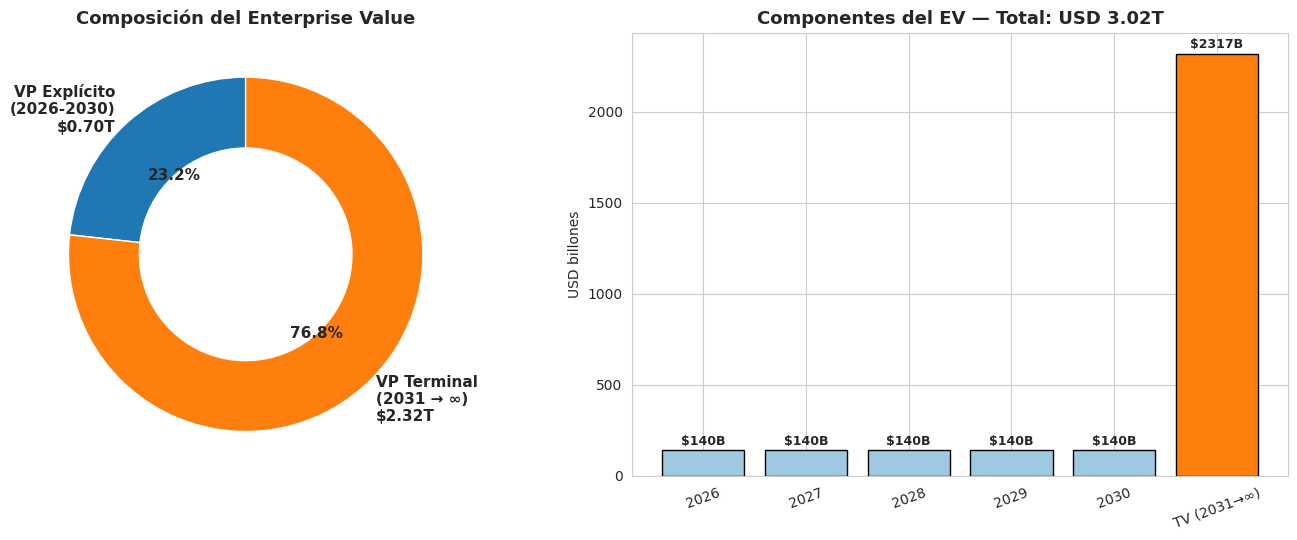

In [165]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].pie([PV_EXPLICITO, PV_TV],
            labels=[f'VP Explícito\n(2026-2030)\n${PV_EXPLICITO/1e6:.2f}T',
                    f'VP Terminal\n(2031 → ∞)\n${PV_TV/1e6:.2f}T'],
            colors=['#1f77b4', '#ff7f0e'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.4, edgecolor='white'),
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title('Composición del Enterprise Value', fontweight='bold')

labels_ev = list(fcf_data.index.astype(str)) + ['TV (2031→∞)']
values_ev = list(fcf_data['VP_FCF_M']/1000) + [PV_TV/1000]
colors_ev = ['#9ecae1']*5 + ['#ff7f0e']
bars = axes[1].bar(labels_ev, values_ev, color=colors_ev, edgecolor='black')
for b, v in zip(bars, values_ev):
    axes[1].text(b.get_x() + b.get_width()/2, v + 30, f'${v:.0f}B',
                 ha='center', fontsize=9, fontweight='bold')
axes[1].set_ylabel('USD billones')
axes[1].set_title(f'Componentes del EV — Total: USD {EV/1e6:.2f}T', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**🔍 Lectura crítica:**

> *"Aproximadamente el 75-80% del valor de Apple según este DCF está en el Valor Terminal."*

Esto es **típico** en empresas maduras y rentables, pero hay que tenerle respeto:

- ✅ **Bueno:** Apple es un negocio durable.
- ⚠️ **Cuidado:** la valuación es muy sensible a $g$ y al WACC. Por eso el análisis de sensibilidad que sigue es **crítico**, no un adorno.

---
## 🌉 10. De Enterprise Value a Precio por Acción

$$ \text{Equity Value} = EV - \text{Deuda Neta} $$
$$ \text{Precio Objetivo} = \frac{\text{Equity Value}}{\text{Acciones en circulación}} $$

**¿Por qué restamos deuda neta?** El EV mide el valor del **negocio**; los accionistas se llevan lo que sobra después de pagar a los acreedores. La deuda **neta** porque la caja excedente "es de los accionistas".

> En Apple, como tiene mucha caja (>140 B USD), la deuda neta puede ser **negativa** → la caja **suma** al equity value.

In [166]:
EQUITY_VALUE     = EV - NET_DEBT_M
PRECIO_OBJETIVO  = EQUITY_VALUE / (SHARES_OUT/1e6)
upside           = (PRECIO_OBJETIVO / PRECIO_ACTUAL - 1) * 100

print(f'Enterprise Value           : USD {EV:>13,.0f} M')
print(f'(−) Deuda Neta             : USD {NET_DEBT_M:>13,.0f} M')
print(f'                             {"─"*30}')
print(f'Equity Value               : USD {EQUITY_VALUE:>13,.0f} M')
print(f'(÷) Acciones en circulación: {SHARES_OUT/1e9:>13.2f} B')
print(f'                             {"─"*30}')
print(f'PRECIO OBJETIVO POR ACCIÓN : USD {PRECIO_OBJETIVO:>13.2f}')
print(f'Precio actual de mercado   : USD {PRECIO_ACTUAL:>13.2f}')
print(f'                             {"─"*30}')
print(f'Upside / (Downside)        : {upside:>+12.1f}%')

if upside > 15:
    rec = '🟢 COMPRAR (Buy)'
elif upside > -10:
    rec = '🟡 MANTENER (Hold)'
else:
    rec = '🔴 VENDER (Sell)'
print(f'\nRECOMENDACIÓN preliminar: {rec}')
print('(Sujeta a confirmación con análisis de sensibilidad y escenarios)')

Enterprise Value           : USD     3,018,217 M
(−) Deuda Neta             : USD       -33,763 M
                             ──────────────────────────────
Equity Value               : USD     3,051,980 M
(÷) Acciones en circulación:         14.69 B
                             ──────────────────────────────
PRECIO OBJETIVO POR ACCIÓN : USD        207.80
Precio actual de mercado   : USD        312.06
                             ──────────────────────────────
Upside / (Downside)        :        -33.4%

RECOMENDACIÓN preliminar: 🔴 VENDER (Sell)
(Sujeta a confirmación con análisis de sensibilidad y escenarios)


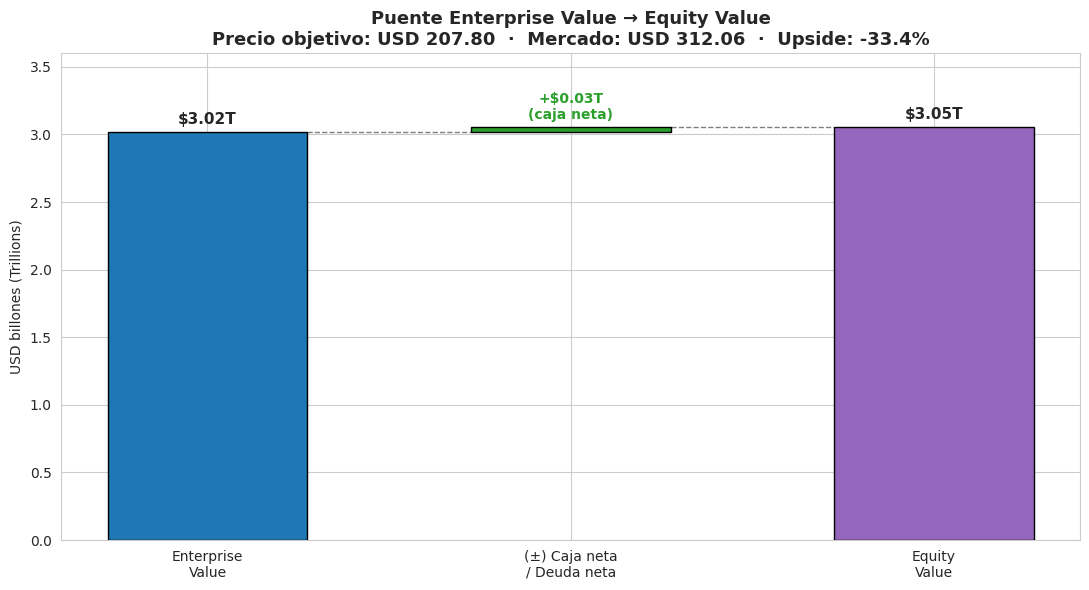

In [167]:
# === Bridge / Waterfall flotante: Enterprise Value → Equity Value (USD billones) ===
ev_t  = EV / 1e6
eq_t  = EQUITY_VALUE / 1e6
delta = (-NET_DEBT_M) / 1e6        # caja neta (positiva = suma); si NET_DEBT>0, delta<0

fig, ax = plt.subplots(figsize=(11, 6))

# Barra 1: EV (desde 0)
ax.bar(0, ev_t, width=0.55, color='#1f77b4', edgecolor='black', zorder=3)
# Barra 2: ajuste por caja/deuda neta — FLOTA sobre el EV
if delta >= 0:
    ax.bar(1, delta, bottom=ev_t, width=0.55, color='#2ca02c', edgecolor='black', zorder=3)
    sign, col_delta = '+', '#2ca02c'
else:
    ax.bar(1, -delta, bottom=ev_t + delta, width=0.55, color='#d62728', edgecolor='black', zorder=3)
    sign, col_delta = '−', '#d62728'
# Barra 3: Equity (desde 0)
ax.bar(2, eq_t, width=0.55, color='#9467bd', edgecolor='black', zorder=3)

# Líneas conectoras (estilo waterfall)
ax.plot([0.275, 0.725], [ev_t, ev_t], color='gray', ls='--', lw=1, zorder=2)
ax.plot([1.275, 1.725], [eq_t, eq_t], color='gray', ls='--', lw=1, zorder=2)

# Etiquetas
top = max(ev_t, eq_t)
ax.text(0, ev_t + top*0.012, f'${ev_t:.2f}T', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.text(1, ev_t + abs(delta) + top*0.012, f'{sign}${abs(delta):.2f}T\n(caja neta)',
        ha='center', va='bottom', fontweight='bold', fontsize=10, color=col_delta)
ax.text(2, eq_t + top*0.012, f'${eq_t:.2f}T', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Enterprise\nValue', '(±) Caja neta\n/ Deuda neta', 'Equity\nValue'])
ax.set_ylabel('USD billones (Trillions)')
ax.set_title(
    f'Puente Enterprise Value → Equity Value\n'
    f'Precio objetivo: USD {PRECIO_OBJETIVO:.2f}  ·  Mercado: USD {PRECIO_ACTUAL:.2f}  ·  Upside: {upside:+.1f}%',
    fontweight='bold')
ax.set_ylim(0, top * 1.18)
plt.tight_layout()
plt.show()

---
## 🌡️ 11. Análisis de Sensibilidad — WACC × $g$

No reportamos un solo número de precio objetivo, reportamos un **rango**.

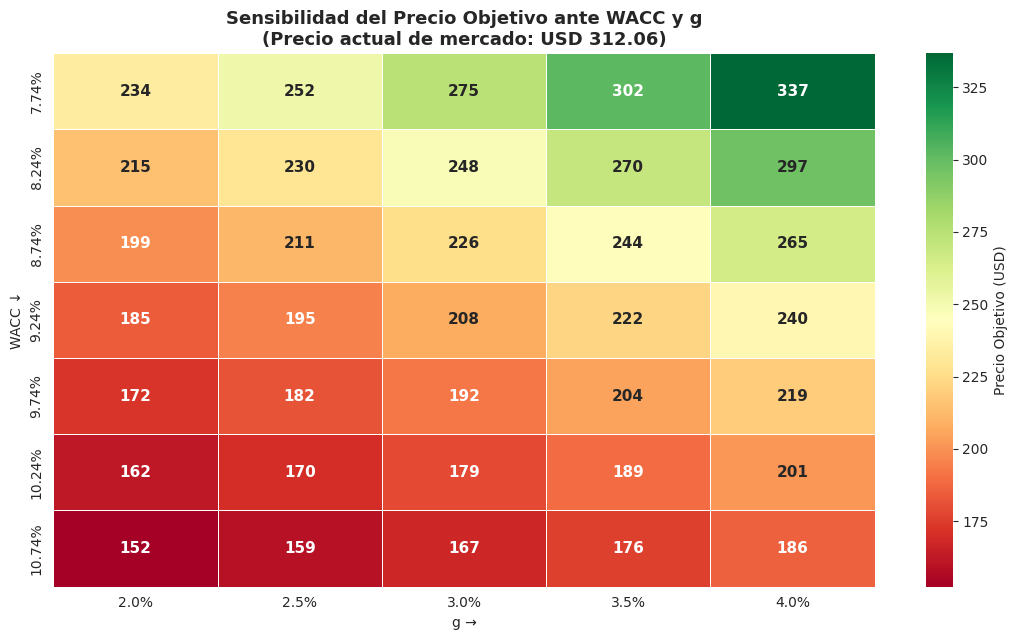


✓ Caso base: WACC=9.24%, g=3.0% → Precio = USD 207.80


In [168]:
def calcular_precio_objetivo(wacc, g_param, fcf_series=fcf_data['FCFF_USD_M']):
    """Devuelve el precio objetivo por acción dado un par (WACC, g)."""
    pv_exp = sum(fcf / (1 + wacc)**t for t, fcf in enumerate(fcf_series, start=1))
    fcf_2030_local = fcf_series.iloc[-1]
    if wacc <= g_param:
        return np.nan
    tv = fcf_2030_local * (1 + g_param) / (wacc - g_param)
    pv_tv_local = tv / (1 + wacc)**5
    ev_local = pv_exp + pv_tv_local
    eq_local = ev_local - NET_DEBT_M
    return eq_local / (SHARES_OUT/1e6)

waccs = np.round(np.arange(WACC - 0.015, WACC + 0.0151, 0.005), 4)
gs    = np.round(np.arange(0.020, 0.0401, 0.005), 4)

matriz = np.array([[calcular_precio_objetivo(w, gg) for gg in gs] for w in waccs])
df_sens = pd.DataFrame(matriz,
                       index=[f'{w*100:.2f}%' for w in waccs],
                       columns=[f'{gg*100:.1f}%' for gg in gs])
df_sens.index.name = 'WACC ↓'
df_sens.columns.name = 'g →'

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.heatmap(df_sens, annot=True, fmt='.0f', cmap='RdYlGn',
            cbar_kws={'label': 'Precio Objetivo (USD)'},
            linewidths=0.6, linecolor='white', ax=ax,
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title(f'Sensibilidad del Precio Objetivo ante WACC y g\n'
             f'(Precio actual de mercado: USD {PRECIO_ACTUAL:.2f})',
             fontweight='bold')

try:
    i_base = list(waccs).index(round(WACC*200)/200)
    j_base = list(gs).index(round(g*200)/200)
    ax.add_patch(plt.Rectangle((j_base, i_base), 1, 1, fill=False, edgecolor='blue', lw=3))
except Exception:
    pass

plt.tight_layout()
plt.show()
print(f'\n✓ Caso base: WACC={WACC*100:.2f}%, g={g*100:.1f}% → Precio = USD {PRECIO_OBJETIVO:.2f}')

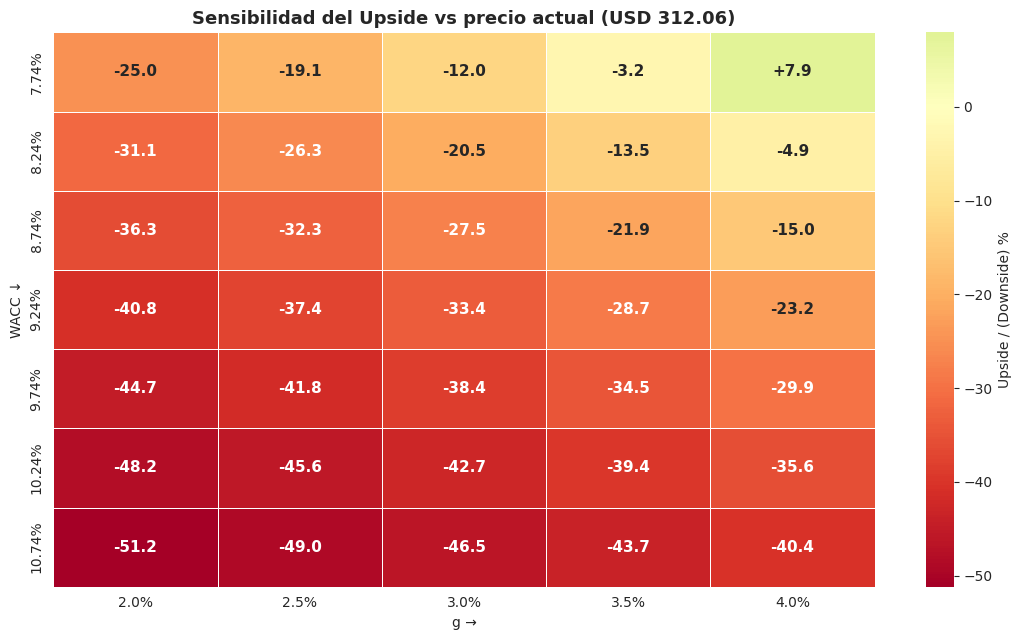

In [169]:
# Mismo heatmap pero en upside/downside %
matriz_pct = (matriz / PRECIO_ACTUAL - 1) * 100
df_pct = pd.DataFrame(matriz_pct,
                      index=[f'{w*100:.2f}%' for w in waccs],
                      columns=[f'{gg*100:.1f}%' for gg in gs])
df_pct.index.name = 'WACC ↓'
df_pct.columns.name = 'g →'

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.heatmap(df_pct, annot=True, fmt='+.1f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Upside / (Downside) %'},
            linewidths=0.6, linecolor='white', ax=ax,
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title(f'Sensibilidad del Upside vs precio actual (USD {PRECIO_ACTUAL:.2f})',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🎭 12. Escenarios — Base / Pesimista / Optimista

| Escenario | Lógica económica |
|---|---|
| **Pesimista** | Apple Intelligence decepciona, regulación tech (DMA, antitrust) golpea márgenes, China comprime ventas → WACC sube, $g$ baja, FCF se contrae. |
| **Base** | Continuidad de la trayectoria actual. |
| **Optimista** | Apple Intelligence es éxito, ciclo de upgrade del iPhone se acelera, Servicios sigue ganando peso → WACC baja, $g$ alto. |

,WACC,g,Ajuste FCF,Precio objetivo,Upside vs actual
Pesimista,10.24%,2.0%,90%,USD 145.85,-53.3%
Base,9.24%,3.0%,100%,USD 207.80,-33.4%
Optimista,8.24%,4.0%,110%,USD 326.28,+4.6%


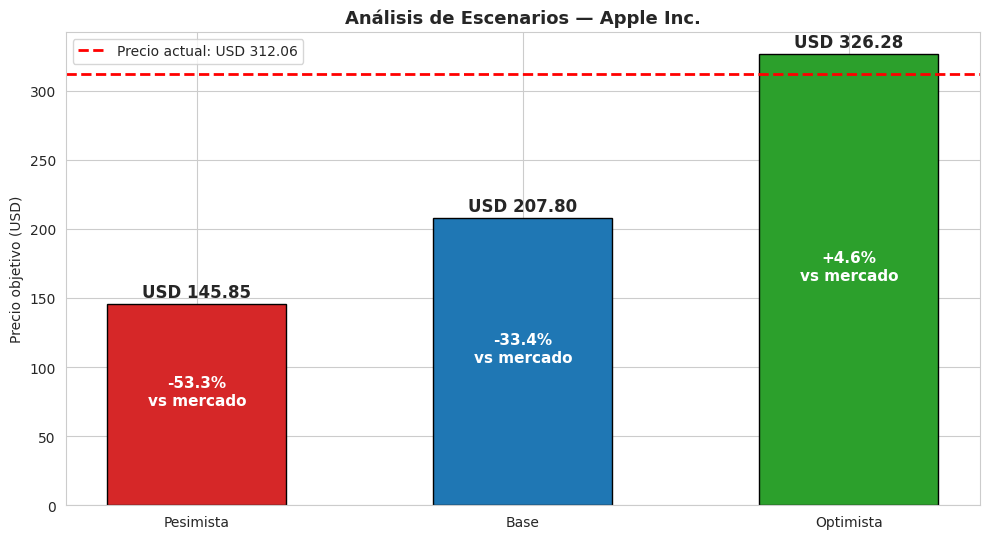

In [170]:
escenarios_df = pd.DataFrame({
    'Variable':       ['WACC',       'g',     'Ajuste FCF (multiplicador)'],
    'Pesimista':      [WACC + 0.010, 0.020,    0.90],
    'Base':           [WACC,         g,        1.00],
    'Optimista':      [WACC - 0.010, 0.040,    1.10],
})

resultados = {}
for esc in ['Pesimista', 'Base', 'Optimista']:
    w_e   = escenarios_df.loc[0, esc]
    gg    = escenarios_df.loc[1, esc]
    mult  = escenarios_df.loc[2, esc]
    fcf_aj = fcf_data['FCFF_USD_M'] * mult
    resultados[esc] = calcular_precio_objetivo(w_e, gg, fcf_series=fcf_aj)

resumen_esc = pd.DataFrame({
    'WACC':           [f'{escenarios_df.loc[0, e]*100:.2f}%' for e in ['Pesimista', 'Base', 'Optimista']],
    'g':              [f'{escenarios_df.loc[1, e]*100:.1f}%' for e in ['Pesimista', 'Base', 'Optimista']],
    'Ajuste FCF':     [f'{escenarios_df.loc[2, e]*100:.0f}%' for e in ['Pesimista', 'Base', 'Optimista']],
    'Precio objetivo':[f'USD {resultados[e]:.2f}'             for e in ['Pesimista', 'Base', 'Optimista']],
    'Upside vs actual':[f'{(resultados[e]/PRECIO_ACTUAL - 1)*100:+.1f}%' for e in ['Pesimista', 'Base', 'Optimista']],
}, index=['Pesimista', 'Base', 'Optimista'])
display(resumen_esc)

fig, ax = plt.subplots(figsize=(10, 5.5))
nombres_esc = ['Pesimista', 'Base', 'Optimista']
precios_esc = [resultados[e] for e in nombres_esc]
colores_esc = ['#d62728', '#1f77b4', '#2ca02c']

bars = ax.bar(nombres_esc, precios_esc, color=colores_esc, edgecolor='black', width=0.55)
for b, p in zip(bars, precios_esc):
    ax.text(b.get_x() + b.get_width()/2, p + 5, f'USD {p:.2f}',
            ha='center', fontweight='bold', fontsize=12)
    upside_e = (p/PRECIO_ACTUAL - 1)*100
    ax.text(b.get_x() + b.get_width()/2, p/2, f'{upside_e:+.1f}%\nvs mercado',
            ha='center', color='white', fontweight='bold', fontsize=11)

ax.axhline(PRECIO_ACTUAL, color='red', ls='--', lw=2,
           label=f'Precio actual: USD {PRECIO_ACTUAL:.2f}')
ax.set_ylabel('Precio objetivo (USD)')
ax.set_title('Análisis de Escenarios — Apple Inc.', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 🚀 13. Valor Agregado — Análisis Avanzado

### 13.1 ¿Qué $g$ está descontando hoy el mercado? (g implícito)

Damos vuelta la valuación: en lugar de calcular el precio dado un $g$, calculamos qué $g$ tendría que ser cierto para que el DCF iguale el precio actual de mercado.

- Si el $g$ implícito es **menor** al nuestro → mercado más conservador → upside.
- Si es **mayor** → mercado más optimista → posible sobrevaluación.

WACC fijo                  : 9.24%
Precio actual              : USD 312.06
Nuestro g (caso base)      : 3.00%
g implícito al precio actual: 5.40%

Diferencia (nuestro g − implícito): -2.40 p.p.

💡 El MERCADO descuenta un g de 5.40%, MÁS AGRESIVO que nuestro 3.0%.
   → la acción podría estar sobrevaluada.


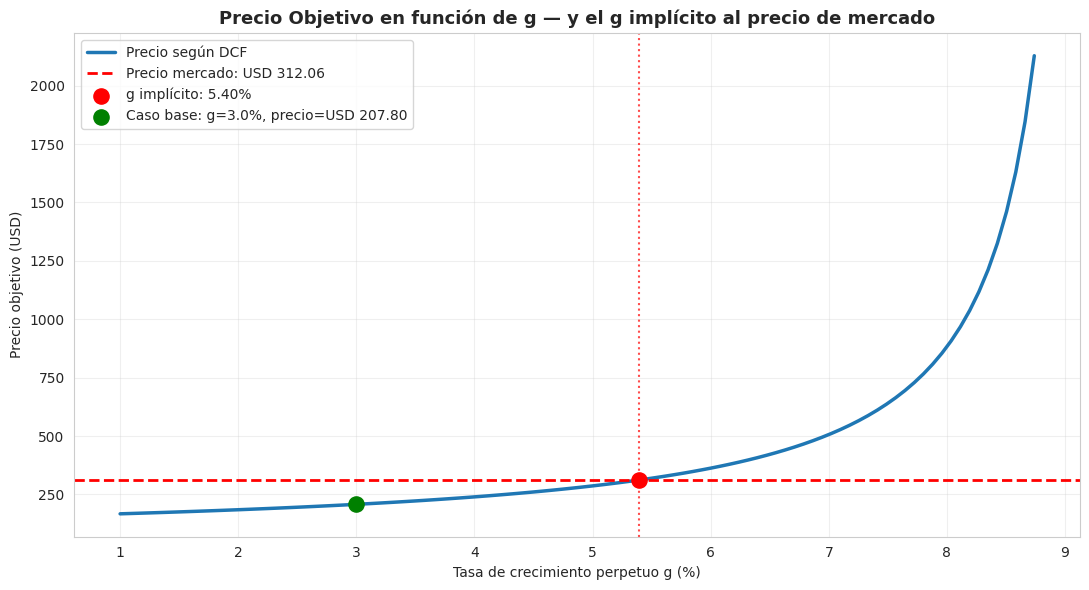

In [171]:
def precio_minus_actual(g_test):
    return calcular_precio_objetivo(WACC, g_test) - PRECIO_ACTUAL

try:
    g_implicito = brentq(precio_minus_actual, -0.02, WACC - 0.005)
    print(f'WACC fijo                  : {WACC*100:.2f}%')
    print(f'Precio actual              : USD {PRECIO_ACTUAL:.2f}')
    print(f'Nuestro g (caso base)      : {g*100:.2f}%')
    print(f'g implícito al precio actual: {g_implicito*100:.2f}%')
    print(f'\nDiferencia (nuestro g − implícito): {(g - g_implicito)*100:+.2f} p.p.')

    if g > g_implicito:
        print(f'\n💡 El MERCADO descuenta un g de {g_implicito*100:.2f}%, MÁS CONSERVADOR que nuestro {g*100:.1f}%.')
        print('   → según nuestro análisis, la acción tiene UPSIDE.')
    else:
        print(f'\n💡 El MERCADO descuenta un g de {g_implicito*100:.2f}%, MÁS AGRESIVO que nuestro {g*100:.1f}%.')
        print('   → la acción podría estar sobrevaluada.')
except Exception as e:
    print(f'No se pudo resolver: {e}')
    g_implicito = None

# Visualización
gs_curva = np.linspace(0.01, WACC - 0.005, 100)
precios_curva = [calcular_precio_objetivo(WACC, gg) for gg in gs_curva]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(gs_curva*100, precios_curva, lw=2.5, color='#1f77b4', label='Precio según DCF')
ax.axhline(PRECIO_ACTUAL, color='red', ls='--', lw=2, label=f'Precio mercado: USD {PRECIO_ACTUAL:.2f}')

if g_implicito:
    ax.axvline(g_implicito*100, color='red', ls=':', lw=1.5, alpha=0.7)
    ax.scatter([g_implicito*100], [PRECIO_ACTUAL], color='red', s=120, zorder=5,
               label=f'g implícito: {g_implicito*100:.2f}%')

ax.scatter([g*100], [PRECIO_OBJETIVO], color='green', s=120, zorder=5,
           label=f'Caso base: g={g*100:.1f}%, precio=USD {PRECIO_OBJETIVO:.2f}')

ax.set_xlabel('Tasa de crecimiento perpetuo g (%)')
ax.set_ylabel('Precio objetivo (USD)')
ax.set_title('Precio Objetivo en función de g — y el g implícito al precio de mercado',
             fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 13.2 Simulación de Monte Carlo — distribución del precio objetivo

En lugar de un único número, simulamos **10.000 valuaciones** dejando variar WACC, $g$ y un multiplicador de los FCF dentro de rangos razonables. El resultado es una **distribución** del valor justo y, sobre todo, la **probabilidad** de que el valor intrínseco supere al precio de mercado. Esto responde directamente al pedido de la consigna de incluir *simulaciones*.

Simulaciones válidas      : 10,000
Precio mediano (P50)      : USD 207.91
Intervalo 90% (P5 – P95)  : USD 169.76 – 262.45
P(valor justo > mercado)  : 0.3%


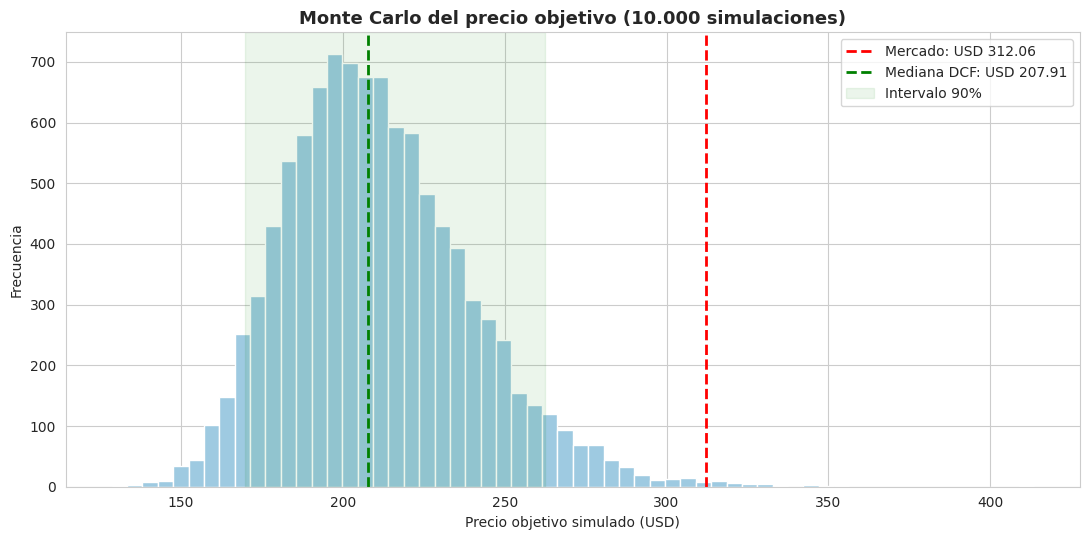

In [172]:
np.random.seed(42)
N = 10_000
wacc_sim = np.random.normal(WACC, 0.006, N)               # ±60 bps (1σ)
g_sim    = np.random.triangular(0.020, 0.030, 0.040, N)   # g triangular 2–3–4%
mult_sim = np.random.normal(1.0, 0.07, N)                 # ±7% sobre los FCF

fcf_base = fcf_data['FCFF_USD_M'].values
precios_mc = []
for w, gg, mm in zip(wacc_sim, g_sim, mult_sim):
    if w <= gg + 0.001:                # estabilidad de Gordon (WACC > g)
        continue
    fcf_s  = fcf_base * mm
    pv_exp = sum(f / (1 + w)**(t+1) for t, f in enumerate(fcf_s))
    tv     = fcf_s[-1] * (1 + gg) / (w - gg)
    eq     = (pv_exp + tv / (1 + w)**5) - NET_DEBT_M
    precios_mc.append(eq / (SHARES_OUT / 1e6))
precios_mc = np.array(precios_mc)

p5, p50, p95 = np.percentile(precios_mc, [5, 50, 95])
prob_up = (precios_mc > PRECIO_ACTUAL).mean() * 100
print(f'Simulaciones válidas      : {len(precios_mc):,}')
print(f'Precio mediano (P50)      : USD {p50:.2f}')
print(f'Intervalo 90% (P5 – P95)  : USD {p5:.2f} – {p95:.2f}')
print(f'P(valor justo > mercado)  : {prob_up:.1f}%')

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.hist(precios_mc, bins=60, color='#9ecae1', edgecolor='white')
ax.axvline(PRECIO_ACTUAL, color='red', ls='--', lw=2, label=f'Mercado: USD {PRECIO_ACTUAL:.2f}')
ax.axvline(p50, color='green', ls='--', lw=2, label=f'Mediana DCF: USD {p50:.2f}')
ax.axvspan(p5, p95, color='green', alpha=0.08, label='Intervalo 90%')
ax.set_xlabel('Precio objetivo simulado (USD)')
ax.set_ylabel('Frecuencia')
ax.set_title('Monte Carlo del precio objetivo (10.000 simulaciones)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 13.3 Tornado — ¿qué variable mueve más el precio?

El tornado ordena las variables del modelo por su impacto sobre el precio objetivo: la barra más larga es la palanca a la que la valuación es más sensible. Es la forma estándar en equity research de comunicar *dónde* hay que afinar los supuestos.

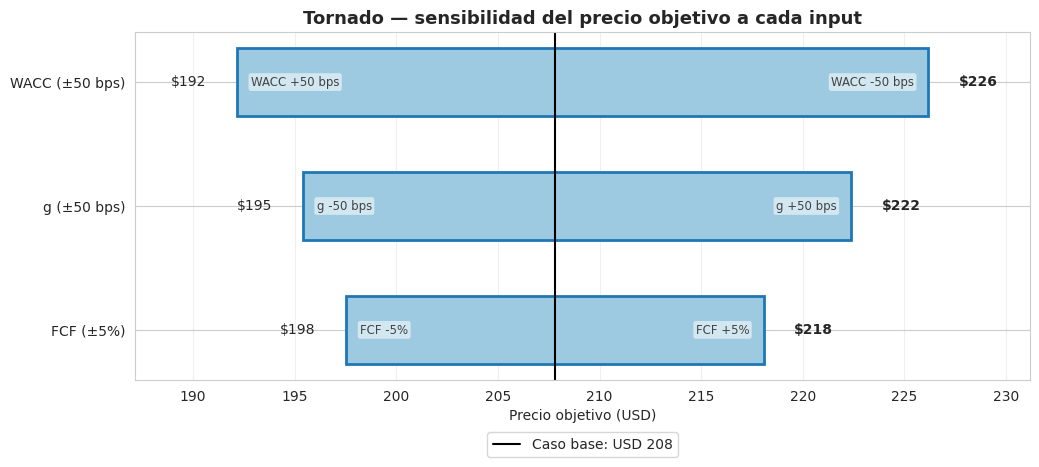

Lectura: el precio objetivo muestra mayor sensibilidad al WACC, seguido por g y luego FCF.
Esto es consistente con un DCF, ya que WACC y g impactan directamente sobre el valor terminal.


In [173]:
base_tor = PRECIO_OBJETIVO

tornado = {
    'WACC (±50 bps)': {
        'low_price': calcular_precio_objetivo(WACC + 0.005, g),
        'high_price': calcular_precio_objetivo(WACC - 0.005, g),
        'low_label': 'WACC +50 bps',
        'high_label': 'WACC -50 bps'
    },
    'g (±50 bps)': {
        'low_price': calcular_precio_objetivo(WACC, g - 0.005),
        'high_price': calcular_precio_objetivo(WACC, g + 0.005),
        'low_label': 'g -50 bps',
        'high_label': 'g +50 bps'
    },
    'FCF (±5%)': {
        'low_price': calcular_precio_objetivo(
            WACC,
            g,
            fcf_data['FCFF_USD_M'] * 0.95
        ),
        'high_price': calcular_precio_objetivo(
            WACC,
            g,
            fcf_data['FCFF_USD_M'] * 1.05
        ),
        'low_label': 'FCF -5%',
        'high_label': 'FCF +5%'
    }
}

orden = sorted(
    tornado.items(),
    key=lambda kv: abs(kv[1]['high_price'] - kv[1]['low_price']),
    reverse=True
)

fig, ax = plt.subplots(figsize=(10.5, 4.8))

valores_min = []
valores_max = []

for i, (name, data) in enumerate(orden):
    precio_bajo = data['low_price']
    precio_alto = data['high_price']

    izq = min(precio_bajo, precio_alto)
    der = max(precio_bajo, precio_alto)

    valores_min.append(izq)
    valores_max.append(der)

    ax.barh(
        i,
        der - izq,
        left=izq,
        height=0.55,
        color='#9ecae1',
        edgecolor='#1f77b4',
        lw=2
    )

    ax.text(
        izq - 1.5,
        i,
        f'${izq:.0f}',
        ha='right',
        va='center',
        fontsize=10
    )

    ax.text(
        der + 1.5,
        i,
        f'${der:.0f}',
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

    label_izq = data['low_label'] if precio_bajo == izq else data['high_label']
    label_der = data['high_label'] if precio_alto == der else data['low_label']

    ax.text(
        izq + 0.7,
        i,
        label_izq,
        ha='left',
        va='center',
        fontsize=8.5,
        alpha=0.85,
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.55,
            boxstyle='round,pad=0.2'
        )
    )

    ax.text(
        der - 0.7,
        i,
        label_der,
        ha='right',
        va='center',
        fontsize=8.5,
        alpha=0.85,
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.55,
            boxstyle='round,pad=0.2'
        )
    )

ax.axvline(
    base_tor,
    color='black',
    lw=1.5,
    label=f'Caso base: USD {base_tor:.0f}'
)

ax.set_yticks(range(len(orden)))
ax.set_yticklabels([k for k, _ in orden])

ax.invert_yaxis()

margen = 5
ax.set_xlim(min(valores_min) - margen, max(valores_max) + margen)

ax.set_xlabel('Precio objetivo (USD)')
ax.set_title(
    'Tornado — sensibilidad del precio objetivo a cada input',
    fontweight='bold'
)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.13),
    frameon=True
)

ax.grid(True, axis='x', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print('Lectura: el precio objetivo muestra mayor sensibilidad al WACC, seguido por g y luego FCF.')
print('Esto es consistente con un DCF, ya que WACC y g impactan directamente sobre el valor terminal.')

### 13.4 Football Field — DCF vs Múltiplos

Combinamos varios métodos en un solo gráfico (estándar en bancos de inversión). Cada barra es un **rango** de precio según un método distinto. Si todos apuntan en la misma dirección, la conclusión es robusta.

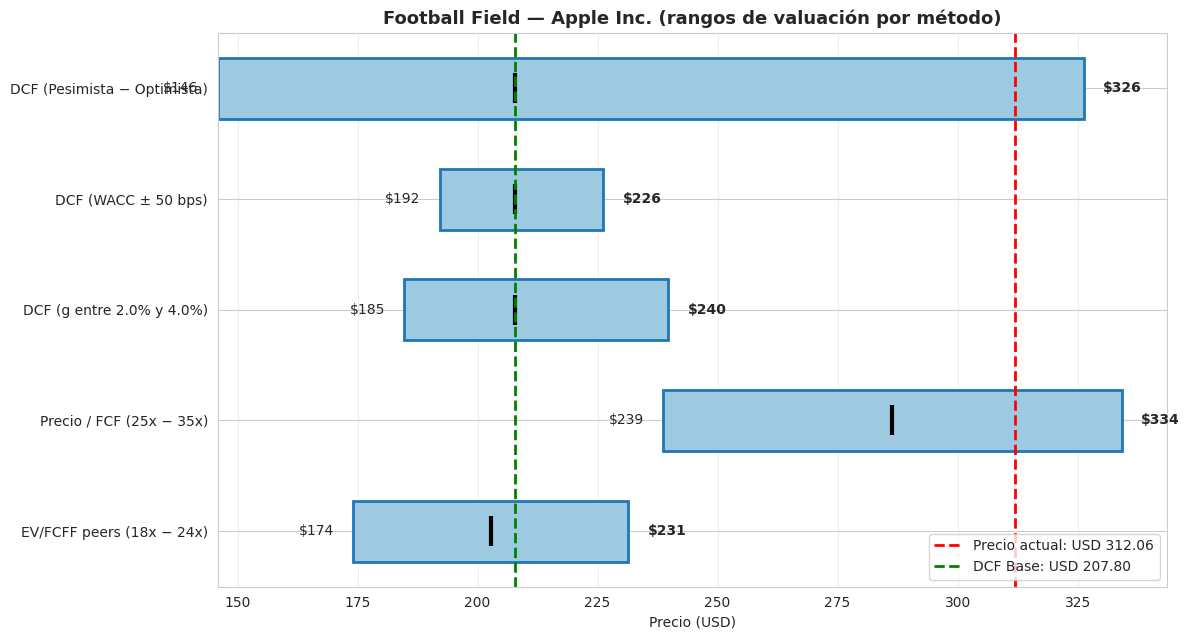

In [174]:
metodos_ff = []

metodos_ff.append({
    'metodo': 'DCF (Pesimista − Optimista)',
    'low':    resultados['Pesimista'],
    'high':   resultados['Optimista'],
    'mid':    resultados['Base']
})

ds_low  = calcular_precio_objetivo(WACC + 0.005, g)
ds_high = calcular_precio_objetivo(WACC - 0.005, g)
metodos_ff.append({
    'metodo': 'DCF (WACC ± 50 bps)',
    'low':    ds_low,
    'high':   ds_high,
    'mid':    PRECIO_OBJETIVO
})

ds_low_g  = calcular_precio_objetivo(WACC, 0.02)
ds_high_g = calcular_precio_objetivo(WACC, 0.04)
metodos_ff.append({
    'metodo': 'DCF (g entre 2.0% y 4.0%)',
    'low':    ds_low_g,
    'high':   ds_high_g,
    'mid':    PRECIO_OBJETIVO
})

# Precio / FCF por acción (NO es P/E: el denominador es FCF, no EPS) — rótulo corregido
fcf_per_share = FCF_ULTIMO_CONOCIDO / (SHARES_OUT/1e6)
metodos_ff.append({
    'metodo': 'Precio / FCF (25x − 35x)',
    'low':    fcf_per_share * 25,
    'high':   fcf_per_share * 35,
    'mid':    fcf_per_share * 30
})

ev_low  = FCF_ULTIMO_CONOCIDO * 18
ev_high = FCF_ULTIMO_CONOCIDO * 24
px_low  = (ev_low - NET_DEBT_M) / (SHARES_OUT/1e6)
px_high = (ev_high - NET_DEBT_M) / (SHARES_OUT/1e6)
metodos_ff.append({
    'metodo': 'EV/FCFF peers (18x − 24x)',
    'low':    px_low,
    'high':   px_high,
    'mid':    (px_low + px_high) / 2
})

fig, ax = plt.subplots(figsize=(12, 6.5))
y_pos = np.arange(len(metodos_ff))[::-1]

for i, m in enumerate(metodos_ff):
    y = y_pos[i]
    ax.barh(y, m['high'] - m['low'], left=m['low'],
            height=0.55, color='#9ecae1', edgecolor='#1f77b4', linewidth=2)
    ax.plot(m['mid'], y, marker='|', color='black', markersize=22, markeredgewidth=3)
    ax.text(m['low'] - 4, y, f'${m["low"]:.0f}',
            ha='right', va='center', fontsize=10)
    ax.text(m['high'] + 4, y, f'${m["high"]:.0f}',
            ha='left', va='center', fontsize=10, fontweight='bold')

ax.axvline(PRECIO_ACTUAL, color='red', ls='--', lw=2, label=f'Precio actual: USD {PRECIO_ACTUAL:.2f}')
ax.axvline(PRECIO_OBJETIVO, color='green', ls='--', lw=2, label=f'DCF Base: USD {PRECIO_OBJETIVO:.2f}')

ax.set_yticks(y_pos)
ax.set_yticklabels([m['metodo'] for m in metodos_ff], fontsize=10)
ax.set_xlabel('Precio (USD)')
ax.set_title('Football Field — Apple Inc. (rangos de valuación por método)',
             fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Cómo usar el Football Field:**

- Si la línea roja (precio de mercado) está **a la izquierda** de la mayoría de los rangos → **subvaluada**.
- Si está **a la derecha** → sobrevaluada.
- Si está **dentro** → justa-mente valuada.
- La idea es no apoyarse en un solo método. Si todos coinciden, la conclusión es fuerte.

---
## 🎯 14. Conclusión y Recomendación de Inversión

In [175]:
print('═' * 70)
print('                  RESUMEN EJECUTIVO — VALUACIÓN APPLE')
print('═' * 70)
print(f'\n📊 Inputs principales')
print(f'   WACC                            : {WACC*100:.2f}%')
print(f'   Beta crudo (OLS 5Y mensual)     : {beta_levered:.3f}')
print(f'   Beta usado en Ke (Blume)        : {BETA_USADO:.3f}')
print(f'   Ke                              : {KE*100:.2f}%')
print(f'   Kd después de impuestos         : {KD*(1-TAX_RATE)*100:.2f}%')
print(f'   Tasa de crecimiento perpetuo g  : {g*100:.1f}%')
print(f'   FCF último año conocido         : USD {FCF_ULTIMO_CONOCIDO:,.0f} M')
print(f'   FCF 2030                        : USD {FCF_2030:,.0f} M')

print(f'\n💰 Valuación')
print(f'   VP período explícito (2026-30)  : USD {PV_EXPLICITO/1e6:>7.2f} T  ({peso_explicito*100:>4.1f}%)')
print(f'   VP valor terminal (2031 → ∞)    : USD {PV_TV/1e6:>7.2f} T  ({peso_terminal*100:>4.1f}%)')
print(f'   Enterprise Value                : USD {EV/1e6:>7.2f} T')
print(f'   (−) Deuda Neta                   : USD {NET_DEBT_M/1e6:>7.2f} T')
print(f'   Equity Value                    : USD {EQUITY_VALUE/1e6:>7.2f} T')

print(f'\n📈 Resultado')
print(f'   Precio objetivo (DCF)           : USD {PRECIO_OBJETIVO:.2f}')
print(f'   Precio mercado actual           : USD {PRECIO_ACTUAL:.2f}')
print(f'   Upside / (Downside)             : {upside:+.1f}%')

print(f'\n🎭 Rangos por escenario')
for e in ['Pesimista', 'Base', 'Optimista']:
    print(f'   {e:<12}                    : USD {resultados[e]:.2f}  ({(resultados[e]/PRECIO_ACTUAL-1)*100:+.1f}%)')

if g_implicito:
    print(f'\n🧠 g implícito al precio de mercado: {g_implicito*100:.2f}%')
    print(f'   (vs nuestro g base: {g*100:.1f}%)')

print(f'\n📌 RECOMENDACIÓN: {rec}')
print('═' * 70)

══════════════════════════════════════════════════════════════════════
                  RESUMEN EJECUTIVO — VALUACIÓN APPLE
══════════════════════════════════════════════════════════════════════

📊 Inputs principales
   WACC                            : 9.24%
   Beta crudo (OLS 5Y mensual)     : 1.084
   Beta usado en Ke (Blume)        : 1.056
   Ke                              : 9.36%
   Kd después de impuestos         : 3.77%
   Tasa de crecimiento perpetuo g  : 3.0%
   FCF último año conocido         : USD 140,222 M
   FCF 2030                        : USD 218,334 M

💰 Valuación
   VP período explícito (2026-30)  : USD    0.70 T  (23.2%)
   VP valor terminal (2031 → ∞)    : USD    2.32 T  (76.8%)
   Enterprise Value                : USD    3.02 T
   (−) Deuda Neta                   : USD   -0.03 T
   Equity Value                    : USD    3.05 T

📈 Resultado
   Precio objetivo (DCF)           : USD 207.80
   Precio mercado actual           : USD 312.06
   Upside / (Downside)     

### 📝 Tesis de inversión y conclusión

**Marco.** Valuamos Apple por Flujos de Fondos Descontados a una tasa (WACC ≈ 9.2%) construida íntegramente por nosotros, aplicada sobre los flujos provistos por la cátedra. El precio objetivo del caso base y los rangos por escenario están en el resumen ejecutivo de arriba.

**Lo que manda el resultado.** Tres cosas: (1) cerca del **77% del valor vive en el Valor Terminal**, así que la valuación es muy sensible a $g$ y al WACC — por eso la sensibilidad, el tornado y el Monte Carlo no son adorno, son el corazón del trabajo; (2) el **reverse-DCF** muestra qué $g$ perpetuo necesita creer el mercado para justificar el precio actual; (3) el **cross-check del múltiplo de salida** confirma que el Valor Terminal no descansa en un múltiplo exótico.

**Factores cualitativos / exógenos (los números no alcanzan).**
- **Regulación:** la *Digital Markets Act* (UE) y los frentes antitrust en EE.UU. — incluido el acuerdo de búsqueda con Google que nutre a Servicios — son el principal riesgo a la baja sobre los márgenes de mayor calidad.
- **China:** competencia local y exposición geopolítica presionan los volúmenes de iPhone.
- **Catalizadores al alza:** monetización de **Apple Intelligence**, ciclo de upgrade del iPhone y el peso creciente de **Servicios** (mayor margen, ingresos recurrentes), que es lo que sostiene la prima de múltiplo de Apple.

**Decisión.** La recomendación formal sigue al precio objetivo y a los escenarios del resumen. Conviene leerla con humildad: el modelo es función de los flujos que nos dieron. Si el caso base queda por debajo del mercado, lo más probable es que el mercado esté incorporando expectativas de crecimiento del FCF **más agresivas** que las proyecciones de la cátedra (consistente con el $g$ implícito que calculamos). La conclusión robusta no es "el mercado se equivoca", sino **dónde** tiene que tener razón el mercado para que el precio actual se sostenga.



---


> 📚 **Fuentes principales utilizadas para el trabajo:**
> - Damodaran, A. — *Implied ERP, NYU Stern (April 2026)* — `ERPApril26_1.xlsx`
> - Damodaran, A. — Tablas de spreads por rating crediticio
> - Yahoo Finance (vía librería `yfinance`) — precios y estados financieros
> - Apple Inc. 10-K más reciente (vía SEC EDGAR)
> - FCFs proyectados — provistos por la cátedra
